# NB12 - all variants side by side

Every configuration tested in the `hyperliquid-lower-vol` track, re-run in one kernel and plotted
against the shared anchor: equity curves, underwater curves, the return-versus-smoothness
trade-off, and one combined metrics table.

**Based on:** the variants defined in [04-backtest-vol-target.ipynb](04-backtest-vol-target.ipynb),
[05-backtest-pool-cap.ipynb](05-backtest-pool-cap.ipynb),
[06-backtest-breadth-concentration.ipynb](06-backtest-breadth-concentration.ipynb),
[07-backtest-drawdown-sizing.ipynb](07-backtest-drawdown-sizing.ipynb) and
[09-backtest-consistency-selection.ipynb](09-backtest-consistency-selection.ipynb), with the shared
harness and adoption rule from [03-smoothing-experiment-plan.md](03-smoothing-experiment-plan.md).
Development window (2026-01-01 to 2026-06-30); the hold-out stays closed.

## Why this notebook exists

Each experiment notebook compares its own family against the anchor, so the families were never
placed on a common axis. Two questions only a combined view answers: whether the families fail in
the same way or in different ways, and whether any of them trades return for smoothness on terms
the others do not. Nothing new is tested here - every configuration is one already run - so this
notebook cannot change a verdict, only make the shape of the results visible.

## Key new insights and what did we learn from this experiment?

- **The measure the track set out to improve is the one most variants made worse.** The ulcer index
  is the most commonly failed constraint: 12 of 22 variants have a *rougher* equity curve than the
  anchor, against 9 failing the CAGR floor, 9 failing on BTC beta and 8 on volatility. Read together
  with the trade-off chart, most of these configurations did not trade return for smoothness at all
  - they gave up return *and* got a bumpier curve. That is a stronger statement than any individual
  notebook made, because each of those compared only within its own family.
- **Only two of 22 variants beat the anchor on both return and smoothness at once**, and they come
  from opposite ends of the sophistication scale. The event-concentration penalty at lambda 0.5
  (55.12% CAGR, 1.31% ulcer) is the most elaborate selection change tested and is a spike that NB11
  rejected. `vol_matched_drop_25` (49.34% CAGR, 1.29% ulcer) is the crudest rule in the track -
  drop the 25 highest-volatility candidates, no view on quality - and it is the one that passes.
- **Families fail in characteristic ways, not by degree, which points at three distinct
  mechanisms.** Every NB07 sizing variant and both NB06 concentration variants fail the same triple
  of volatility, ulcer and beta: re-weighting an unchanged basket moves risk around without reducing
  it. The NB09 consistency legs fail CAGR, volatility and ulcer together: they buy a low beta by
  selecting vaults that do not earn. The NB04 volatility targets fail on a *single* constraint each
  - beta at the looser targets, CAGR at the tightest - making that the family that came closest
  without ever clearing the bar.
- **Four configurations pass all five constraints, and three of them are the same idea.**
  `min_tvl_25k` plus `vol_matched_drop` at 25, 30 and 35. Both surviving ideas are exclusion rules
  that shrink the candidate pool before ranking - raise the TVL floor, or drop the most volatile
  names - rather than changes to how the surviving candidates are scored or sized. Every attempt to
  improve the *score* failed. That is the clearest signal this track produced about where to look
  next, and it cuts against the plan's own premise, which was that the allocation formula was the
  thing to fix.

## Summary of results

22 variants plus the anchor, re-run in one kernel on the development window. Every figure reproduces
its source notebook exactly, which also serves as a cross-check that the shared harness is
deterministic across notebooks.

| Passing all five constraints | CAGR | Ulcer | Martin | Beta |
|------------------------------|------|-------|--------|------|
| anchor | 48.76% | 1.40% | 34.77 | 0.0711 |
| vol_matched_drop_30 | 48.00% | 1.22% | 39.25 | 0.0637 |
| vol_matched_drop_35 | 47.31% | 1.23% | 38.54 | 0.0578 |
| vol_matched_drop_25 | 49.34% | 1.29% | 38.20 | 0.0681 |
| min_tvl_25k | 32.89% | 1.12% | 29.25 | 0.0447 |

Constraint failures across the 22 variants: ulcer 12, CAGR floor 9, beta 9, volatility 8.

## Robustness of results

- **This notebook cannot change a verdict and does not try to.** Every configuration was already run
  in its own notebook; the value here is the common axis. Both the leave-one-vault-out checks that
  rejected `vol_matched_drop_30` and `min_tvl_25k` and the plateau check that rejected the
  event-concentration penalty live in NB05, NB09 and NB11, and nothing here overturns them - the
  four "passing" rows above are passing the *constraints*, not the full adoption rule.
- **The trade-off chart's marker sizes encode beta, which flatters the low-return variants.** The
  smallest markers belong to configurations like `min_tvl_100k` and `assets_10` that reach a low
  beta by barely trading, so a small marker is only meaningful in the top-left quadrant.
- **All 22 runs share one development window and one universe vintage**, so the failure-mode
  clustering describes this period, not the mechanism in general. NB03a already showed the window
  does not contain the BTC-beta episode the track was aimed at.
- **Equity curves are plotted in dollars from a common $150,000 start**, so they are directly
  comparable, but the underwater chart is each run against its own running peak, which is the right
  basis for comparing drawdown shape and the wrong one for comparing absolute loss.


## Notebook setup

- Shared imports, chart output settings, and notebook logging for the clean single backtest.

In [1]:
import datetime
import logging

import pandas as pd
import plotly.express as px
from IPython.display import display

from tradingstrategy.client import Client
from tradeexecutor.utils.notebook import setup_charting_and_output, OutputMode

client = Client.create_jupyter_client()
setup_charting_and_output(OutputMode.static, image_format='png', width=1500, height=1000)
logger = logging.getLogger('strategy')

Started Trading Strategy in Jupyter notebook environment, configuration is stored in /Users/moo/.tradingstrategy


## Universe definition

- Use the same Hyperliquid survivor-first vault universe as the parent notebook so the accounting comparison is direct.


In [2]:
from eth_defi.token import USDC_NATIVE_TOKEN
from tradingstrategy.chain import ChainId
from tradeexecutor.state.identifier import AssetIdentifier

CHAIN_ID = ChainId.hyperliquid

EXCHANGES = ('uniswap-v2', 'uniswap-v3')
SUPPORTING_PAIRS = [
    (ChainId.arbitrum, 'uniswap-v3', 'WETH', 'USDC', 0.0005),
    (ChainId.ethereum, 'uniswap-v3', 'WETH', 'USDC', 0.0005),
    (ChainId.ethereum, 'uniswap-v3', 'WBTC', 'USDC', 0.003),
]
LENDING_RESERVES = None
PREFERRED_STABLECOIN = AssetIdentifier(
    chain_id=ChainId.hyperliquid.value,
    address=USDC_NATIVE_TOKEN[ChainId.hyperliquid].lower(),
    token_symbol='USDC',
    decimals=6,
)
ALLOWED_VAULT_DENOMINATION_TOKENS = {'USDC', 'USDT', 'USDC.e', 'crvUSD', 'USDT0', 'USD₮0', 'USDt', 'USDS'}

print(f'Chain universe: {CHAIN_ID.get_name()}')
print(f'Reserve asset: {PREFERRED_STABLECOIN}')


Chain universe: HyperEVM
Reserve asset: <USDC at 0xb88339cb7199b77e23db6e890353e22632ba630f>


## Parameters

- The parent configuration is unchanged except for redemption accounting.
- Each redemption charges a 10% fee on positive profit and 10 bps of gross redeemed capital.


In [3]:
from tradeexecutor.strategy.cycle import CycleDuration
from tradeexecutor.strategy.default_routing_options import TradeRouting
from tradeexecutor.strategy.parameters import StrategyParameters

from tradingstrategy.timebucket import TimeBucket


class Parameters:
    #: Notebook identifier.
    id = '12-research-variant-comparison'

    #: Daily candles match the whole Hyperliquid survivor-first research chain.
    candle_time_bucket = TimeBucket.d1
    #: Native 2-day rebalance cadence. NB63, NB64 and NB65 all settled on 48 hours, and NB65
    #: verified a native `cycle_2d` reproduces NB64's modulo-counter version to within 0.36 pp, so
    #: the cadence is pinned here rather than searched and the modulo counter is retired.
    #:
    #: Relies on the trade-executor fix that makes `perform_optimisation()` forward
    #: `cycle_duration`; without it the optimiser silently reverts to a daily clock.
    cycle_duration = CycleDuration.cycle_2d
    #: HyperEVM is the primary chain for vaults.
    chain_id = CHAIN_ID
    #: HyperEVM is the primary execution chain.
    primary_chain_id = CHAIN_ID
    #: Same exchange set as the release-candidate notebooks.
    exchanges = EXCHANGES

    #: **Searched.** NB68 found 6 best on CAGR and 8 best on Sharpe/Calmar/drawdown at 150,000,
    #: with a reproducible hole at 7 - so the axis is not monotone and the optimum depends on the
    #: objective. Searched jointly here rather than settled by eye.
    #: **NB92 winner.** NB92's recommendation and an interior optimum confirmed from both sides: mean CAGR
    #: 5 -> 20.82%, 6 -> 21.89%, 7 -> 15.27%, 8 -> 15.60%. Opening the range down to 5 confirmed 6
    #: rather than moving the optimum.
    max_assets_in_portfolio = 6
    #: 98% target deployment, the validated release default.
    allocation_pct = 0.98
    #: **Searched.** The one parameter known to reverse with capital: NB65 measured 33% > 50% at
    #: 25,000, NB68 measured 50% > 33% at 150,000. At large size the ceiling stops being risk
    #: control and becomes a deployment constraint.
    max_concentration_pct = 0.33
    #: **Searched.** The best-evidenced lever in the chain: NB67 measured 15% -> 25% as worth
    #: +4.61 pp at 75,000 and +20.34 pp at 150,000, and NB68 confirmed a gain in all six
    #: combinations tested. 0.30 extends past anything measured so far.
    per_position_cap_of_pool_pct = 0.33
    #: Engine hygiene threshold for cleaning up tiny residual positions.
    min_portfolio_weight_pct = 0.005

    #: Retired: the cadence is now the engine's own 2-day cycle, so every cycle acts.
    rebalance_every_n_cycles = 1
    #: Retired from the search: NB63 and NB64 both found it inert at or below the cadence and
    #: harmful above it, and NB69/NB70 confirmed no configuration wanted it.
    minimum_hold_days = 1

    #: Hyperliquid has a hard 5 USD minimum deposit.
    absolute_min_vault_deposit_usd = 5.0
    #: Buy threshold as a fraction of initial cash. Deposits are free under an exit-only
    #: fee, so the buy side stays tight and is not searched.
    individual_rebalance_min_threshold_of_initial_cash_pct = 0.0005
    #: **Searched.** Sell-side softband in USD at a 150,000 bankroll: the $5 hard floor plus
    #: 0.25%, 0.5% and 1.0% of capital.
    #:
    #: The ladder stops at 1%. NB66 established the crash boundary is a fraction of capital -
    #: between 1% and 2% at every bankroll tested - because suppressed sells are not deducted from
    #: the buy budget, so a wide band lets the plan spend proceeds from a trim it then cancels.
    #: NB67 confirmed $3,000 (2%) and $6,000 (4%) both fail at 150,000 while $1,500 (1%) survives.
    #: 1% is the edge rather than a safe margin, so any crash at that rung is surfaced below
    #: instead of being scored as a zero.
    sell_rebalance_min_threshold_usd = 750.0

    #: Survivor-first TVL floor selected in NB141.
    min_tvl_usd = 7_500

    #: Trailing window (days) for the CAGR leg of the composite selection score.
    cagr_lookback_days = 360
    #: Trailing window (days) for the Sharpe leg of the composite selection score.
    sharpe_lookback_days = 45
    #: Composite blend: ``cagr_weight x CAGR score + (1 - cagr_weight) x Sharpe score``.
    #: NB31 showed both legs are load-bearing: either leg alone is materially worse on
    #: both CAGR and drawdown.
    #: **NB92 winner.** NB92's recommendation, and a value no earlier search in this chain contained - NB90 ran
    #: 0.3/0.5/0.7 and settled on 0.5, stepping straight over the optimum. All 15 of NB92's top
    #: configurations use 0.6, at 100% consensus.
    #:
    #: This is the top of NB92's range and 0.7 was dropped from it on a marginal mean measured
    #: under different companion values, so whether 0.7 is better is still open.
    cagr_weight = 0.60
    #: Momentum gate window: a vault is eligible only while its trailing return over
    #: this window exceeds :py:attr:`gate_threshold`. NB31: pure drawdown insurance at
    #: zero return cost (removal: -4.5pp CAGR and max DD -7.4% -> -17.5%).
    gate_lookback_days = 14
    #: Momentum gate threshold (fraction).
    #: **NB92 winner.** Unchanged. NB92 confirmed this axis is inert across a range 50% wider than NB90's: mean CAGR
    #: spans only 17.52% to 19.54% across all six searched values, and the two newly opened
    #: permissive values changed nothing.
    gate_threshold = -0.16
    #: **Searched.** The window for the volatility estimate that becomes the sizing weight.
    #:
    #: NB70 found a broad 45-60 day plateau with sharp falloff either side and no reason to move
    #: off 60 on its own - but it also found the exponent and the window are separate levers, and
    #: the window was last searched (NB28/NB29) on data that was 41% forward-filled. It is in the
    #: search because it interacts with everything else here, not because 60 looked wrong.
    #:
    #: This is an **indicator** parameter. `prepare_grid_combinations()` calls
    #: `create_indicators()` with each combination's own parameters, so every value gets its own
    #: indicator series - unlike a hand-built grid, where reusing a precomputed indicator set
    #: would silently give every cell the same 60-day series.
    #: **NB92 winner.** NB92's recommendation and a genuine interior optimum: mean CAGR 60 -> 18.44%, 75 -> 19.93%,
    #: 90 -> 21.03%, 105 -> 16.04%. The collapse at 105 is what makes 90 interior rather than a
    #: boundary artefact.
    #:
    #: Chosen over the higher-scoring window-60 configurations deliberately. Those returned up to
    #: 34.12% but their worst one-step neighbour falls to 11-12%, because 60 is a boundary and the
    #: step off it lands on the sharpe_lookback_days cliff. At 90 the worst neighbour holds at
    #: 31.69%.
    inverse_vol_window = 90

    #: Pinned: size by 1/sigma^2 rather than 1/sigma. NB72 measured +2.77 pp of CAGR at 60 days,
    #: winning at 7 of 7 lookbacks on both the full window and clean daily data, with a genuine
    #: interior optimum at k=2. Note the gain is return-only - Sharpe moved +0.02 and drawdown
    #: 0.57 pp worse - so this pins the return-maximising choice, and the search below optimises
    #: Sharpe, which will not reward it for that.
    #: Selection score. ``cagr_sortino_weight`` replaces the Sharpe leg of the incumbent composite
    #: with Sortino, which is the change NB79 measured at +0.869 Sharpe on a single configuration.
    #: This notebook exists to find out whether that survives a search.
    selection_score_indicator = 'cagr_sortino_weight'

    #: Sizing rule, searched rather than pinned. NB71 and NB72 showed the ranking between these two
    #: **reverses with the concentration cap** - inverse variance wins at 33% and loses at 25% - so
    #: it cannot be assumed to carry over to a different selection score. NB77 gives a further
    #: reason to re-test it here: inverse variance weights by the reciprocal of variance, so it
    #: hands the largest positions to the low-volatility cohort that loses most often.
    weighting_method = 'inverse_variance'


    #: Unused while :py:attr:`weighting_method` is ``inverse_variance``; kept so the sizing helper
    #: has a value for every branch.
    weighting_exponent = 2.0
    softmax_temperature = 0.25

    #: Start trading from January 2026 while retaining pre-start indicator history.
    backtest_start = datetime.datetime(2026, 1, 1)
    #: Exclusive end boundary. Extended to "yesterday" for the lower-vol track baseline;
    #: vault price history is now pulled fresh from the Trading Strategy website each run.
    #: Development window end (exclusive). The hold-out (2026-07-01 to 2026-09-08) is
    #: reserved and opened only in NB11 (03-smoothing-experiment-plan.md).
    backtest_end = datetime.datetime(2026, 7, 1)
    #: Release-candidate bankroll.
    initial_cash = 150_000
    #: Derived at class creation time from the configured initial cash and the 5 USD hard floor.
    individual_rebalance_min_threshold_usd = max(
        absolute_min_vault_deposit_usd,
        initial_cash * individual_rebalance_min_threshold_of_initial_cash_pct,
    )

    #: Optimiser runs do not model managed yield.
    use_managed_yield = False

    #: Margin withheld by the same-cycle buy cap. Sell proceeds are sized at
    #: mark-to-market value but execute slightly lower due to redemption fees,
    #: price movement, and raw-unit rounding.
    sync_cash_headroom_usd = max(0.50, initial_cash * 0.0005)

    #: Default routing is still required by the strategy runtime even though it is not the alpha source.
    routing = TradeRouting.default
    #: Set deliberately high so live and notebook indicator calculations use effectively
    #: all available history; history-derived indicators would be silently biased by a
    #: truncated lookback window.
    required_history_period = datetime.timedelta(days=365 * 20)
    #: Same live-style slippage assumption as the release-candidate notebooks.
    slippage_tolerance_pct = 0.0060
    #: Performance fee charged only on positive profit at redemption.
    vault_performance_fee = 0.10
    #: Fixed capital fee charged on every redemption, including loss-making redemptions.
    vault_redemption_capital_fee = 0.0010
    #: Assume no liquidity if there is a gap in TVL data.
    assummed_liquidity_when_data_missings_usd = 0.01

    #: --- hyperliquid-lower-vol smoothing track additions (see 03-smoothing-experiment-plan.md) ---
    #: Rolling window for `btc_beta` / `btc_beta_r2`.
    beta_window_days = 90
    #: Rolling window for `fresh_observation_count`.
    fresh_window_days = 90
    #: Minimum fresh (non-zero-return) observations before a staleness-sensitive statistic is trusted.
    min_fresh_observations = 60
    #: Window for `ulcer_index_180`.
    ulcer_window_days = 180
    #: Window for `downside_deviation_90`.
    downside_window_days = 90
    #: Rolling-return window and lookback span for `positive_window_share`.
    consistency_window_days = 30
    consistency_span_days = 180
    #: Window for `residual_event_concentration`.
    event_window_days = 180
    #: Window for `gain_to_pain_score`.
    gain_to_pain_window_days = 180
    #: NB04: target annualised portfolio volatility. None disables vol targeting (anchor behaviour).
    target_portfolio_vol = None
    #: NB07: which per-vault risk indicator sizes the basket when `weighting_method` is
    #: `inverse_ulcer` or `inverse_downside`.
    sizing_risk_indicator = 'inverse_vol'
    #: NB07: floor on any sizing weight as a fraction of the mean weight, so a vault whose risk
    #: measure reads as near-zero (often because its marks are stale) cannot swallow the basket.
    weight_floor_fraction = 0.25
    #: NB07: maximum combined weight share for vaults with |btc_beta| above `beta_high_threshold`.
    #: None disables the group cap (anchor behaviour).
    high_beta_group_cap = None
    beta_high_threshold = 0.6
    #: NB08: multiply the composite by `1 - lambda * clip(residual_event_concentration, 0, 1)`.
    event_concentration_lambda = 0.0
    #: NB08: blend weight for the gain-to-pain tiebreak, `0` disables it (anchor behaviour).
    gain_to_pain_tilt = 0.0
    #: NB09: if True, a vault with a NaN composite is dropped from candidates instead of scored 0.
    require_scored_candidates = False
    #: NB07 (plan item): equal-risk-contribution sizing accounts for how correlated the selected
    #: vaults are, not just how volatile each one is. Vaults whose mean absolute correlation to the
    #: rest of the basket exceeds this cap are shrunk further.
    residual_correlation_cap = 0.60
    #: NB09 control: drop this many of the highest-volatility candidates each cycle before ranking.
    #: The pre-registered vol-matched placebo (NB42's control): if dropping names purely by
    #: volatility reproduces a selection change's risk reduction, that change is generic
    #: de-risking rather than selection skill. `0` disables it (anchor behaviour).
    vol_matched_drop_count = 0
    #: NB10: shrink `btc_beta` toward zero before building the residual CAGR leg (estimation-noise
    #: control). `1.0` is full beta (anchor behaviour for the residual variant).
    beta_shrink = 1.0


parameters = StrategyParameters.from_class(Parameters)

from tradeexecutor.strategy.parameters import display_parameters

display_parameters(parameters)


,Value,Type
Name,,
absolute_min_vault_deposit_usd,5.0,float
allocation_pct,0.98,float
assummed_liquidity_when_data_missings_usd,0.01,float
backtest_end,2026-07-01 00:00:00,datetime
backtest_start,2026-01-01 00:00:00,datetime
beta_high_threshold,0.6,float
beta_shrink,1.0,float
beta_window_days,90,int
cagr_lookback_days,360,int


## Trading universe

- Build the tradable supporting-pair and Hyperliquid vault universe used by the backtest.

In [4]:
from pathlib import Path
import shutil
import time

from dotenv import load_dotenv
from tradingstrategy.utils.token_filter import filter_for_selected_pairs
from tradeexecutor.analysis.pair import display_strategy_universe
from tradeexecutor.strategy.execution_context import notebook_execution_context
from tradeexecutor.strategy.pandas_trader.trading_universe_input import CreateTradingUniverseInput
from tradeexecutor.strategy.trading_strategy_universe import TradingStrategyUniverse, load_partial_data, load_vault_universe_with_metadata
from tradeexecutor.strategy.universe_model import UniverseOptions
from tradeexecutor.utils.notebook import display_dataframe_with_html, display_head_and_tail

from tradeexecutor.curator import build_hyperliquid_vault_universe

load_dotenv(override=True)

# Vault price history is downloaded fresh from the Trading Strategy website into the standard
# Trading Strategy cache (`~/.cache/tradingstrategy`) rather than copied from a machine-specific
# frozen archive. `load_partial_data(..., vault_history_download_root=None)` resolves the cache
# path from the oracle client, so no custom cache directory is needed.


def create_trading_universe(
    input: CreateTradingUniverseInput,
) -> TradingStrategyUniverse:
    """Create the release-candidate trading universe.

    Keep the backtest trading window fixed to `Parameters.backtest_start` /
    `Parameters.backtest_end`, but let `required_history_period` extend the
    data-loading window backwards so age and other history-derived indicators
    can see the full pre-backtest history for the selected vaults.
    """
    execution_context = input.execution_context
    client = input.client
    timestamp = input.timestamp
    parameters = input.parameters or Parameters
    universe_options = input.universe_options

    debug_printer = logger.info if execution_context.live_trading else print

    chain_id = parameters.primary_chain_id
    debug_printer(f'Preparing trading universe on chain {chain_id.get_name()}')

    all_pairs_df = client.fetch_pair_universe().to_pandas()
    pairs_df = filter_for_selected_pairs(all_pairs_df, SUPPORTING_PAIRS)
    debug_printer(f'We have total {len(all_pairs_df)} pairs in dataset and going to use {len(pairs_df)} pairs for the strategy')

    # Full, non-survivorship-biased universe: `top_n=None` still applies the
    # 120-vault CAGR cap baked into `CHAIN_CONFIG[9999]["top_n"]`, so pass an
    # explicit oversized `top_n` to keep every eligible Hyperliquid vault.
    source_vaults = build_hyperliquid_vault_universe(
        min_tvl=parameters.min_tvl_usd,
        min_age=0.0,
        top_n=9999,
    )
    vault_universe = load_vault_universe_with_metadata(client, vaults=source_vaults)
    vault_universe = vault_universe.limit_to_denomination(ALLOWED_VAULT_DENOMINATION_TOKENS, check_all_vaults_found=True)
    debug_printer(f'Loaded {vault_universe.get_vault_count()} vaults from remote vault metadata, source vaults count: {len(source_vaults)}')

    # `load_partial_data()` now honours `required_history_period` in backtests
    # as a loader-window extension instead of clipping history to the trading window.
    dataset = load_partial_data(
        client=client,
        time_bucket=parameters.candle_time_bucket,
        pairs=pairs_df,
        execution_context=execution_context,
        universe_options=universe_options,
        liquidity=True,
        liquidity_time_bucket=TimeBucket.d1,
        lending_reserves=LENDING_RESERVES,
        vaults=vault_universe,
        vault_history_source="trading-strategy-website",
        check_all_vaults_found=True,
    )

    return TradingStrategyUniverse.create_from_dataset(
        dataset,
        reserve_asset=PREFERRED_STABLECOIN,
        forward_fill=True,
        forward_fill_until=timestamp,
        primary_chain=parameters.primary_chain_id,
    )


universe_input = CreateTradingUniverseInput(
    execution_context=notebook_execution_context,
    client=client,
    timestamp=None,
    parameters=parameters,
    universe_options=UniverseOptions.from_strategy_parameters_class(Parameters, notebook_execution_context),
    execution_model=None,
)

strategy_universe = create_trading_universe(universe_input)
df = display_strategy_universe(
    strategy_universe,
    sort_key='base',
    sort_numeric=False,
    limit=75,
    show_token_risk=True,
    show_tokensniffer=True,
)
display_head_and_tail(df, head_rows=5, tail_rows=5)


def apply_vault_redemption_capital_fee(universe, fee) -> int:
    """Set the fixed redemption-capital fee on every vault pair.

    The performance-fee component is position-specific and changes with the
    position's remaining cost basis. It is refreshed immediately before each
    portfolio decision in :func:`refresh_vault_redemption_accounting`.
    """
    assert 0 <= fee < 0.10, f"Redemption fee does not look real: {fee}"
    count = 0
    for pair in universe.iterate_pairs():
        if not pair.is_vault():
            continue
        assert pair.can_have_tax(), f"Vault pair cannot carry a sell-side fee: {pair}"
        pair.base.other_data["sell_tax"] = fee
        count += 1
    return count


fee_applied = apply_vault_redemption_capital_fee(
    strategy_universe,
    Parameters.vault_redemption_capital_fee,
)
print(
    f'Applied a {Parameters.vault_redemption_capital_fee * 10_000:.0f} BPS '
    f'capital fee to {fee_applied} vault pairs; performance fees are refreshed per position.'
)


Preparing trading universe on chain HyperEVM


We have total 392255 pairs in dataset and going to use 3 pairs for the strategy
Hypercore universe fingerprint: bbf10d84
Loaded 339 cached Hypercore vaults (tvl7500-top9999-age0.0-sort1Y-curbbf10d84)


Loaded 339 vaults from remote vault metadata, source vaults count: 339


Loading TVL/liquidity data for 3 pairs:   0%|          | 0/3 [00:00<?, ?it/s]

Loading TVL/liquidity data for 3 pairs: 100%|██████████| 3/3 [00:00<00:00, 342.20it/s]

Results limited to first 75 entries
Head (5 rows)


,base,quote,exchange,type,fee %,price,first_price_at,last_price_at,volume,tvl,tvl_at,tax,tokensniffer_risk_score,token_risk_score,token_risk_flags,pfee,mfee
id,,,,,,,,,,,,,,,,,
278548699,Sistema I,USDC,hyperliquid,traded,NaN,0.80,2026-01-21 00:00:00,71 days 00:00:00,0.00,"12,433",70 days 00:00:00,- / -,None,None,-,10.0%,0.0%
282757120,$NIKEPIG's,USDC,hyperliquid,traded,NaN,0.70,2026-01-14 00:00:00,71 days 00:00:00,0.00,"30,403",70 days 00:00:00,- / -,None,None,-,10.0%,0.0%
268714989,$🏧| ATM |🏧,USDC,hyperliquid,traded,NaN,,-,-,0.00,292,70 days 00:00:00,- / -,None,None,-,10.0%,0.0%
284367427,-VectorZer,USDC,hyperliquid,traded,NaN,1.95,2025-01-01 00:00:00,71 days 00:00:00,0.00,"69,291",70 days 00:00:00,- / -,None,None,-,10.0%,0.0%
269753871,0xBTC脉冲,USDC,hyperliquid,traded,NaN,0.93,2026-01-27 00:00:00,71 days 00:00:00,0.00,"28,980",70 days 00:00:00,- / -,None,None,-,10.0%,0.0%


Tail (5 rows)


,base,quote,exchange,type,fee %,price,first_price_at,last_price_at,volume,tvl,tvl_at,tax,tokensniffer_risk_score,token_risk_score,token_risk_flags,pfee,mfee
id,,,,,,,,,,,,,,,,,
276885198,Cycle Mode,USDC,hyperliquid,traded,NaN,0.25,2025-11-19 00:00:00,71 days 00:00:00,0.00,"4,277",70 days 00:00:00,- / -,None,None,-,10.0%,0.0%
269792829,DH-Funding,USDC,hyperliquid,traded,NaN,0.83,2025-05-28 00:00:00,71 days 00:00:00,0.00,"5,857",70 days 00:00:00,- / -,None,None,-,10.0%,0.0%
271101545,DOEZOE,USDC,hyperliquid,traded,NaN,1.73,2025-06-04 00:00:00,71 days 00:00:00,0.00,"17,008",70 days 00:00:00,- / -,None,None,-,10.0%,0.0%
278620567,DailyTrade,USDC,hyperliquid,traded,NaN,0.07,2024-08-14 00:00:00,71 days 00:00:00,0.00,"34,593",70 days 00:00:00,- / -,None,None,-,10.0%,0.0%
280434712,DaoScience,USDC,hyperliquid,traded,NaN,1.39,2026-02-21 00:00:00,71 days 00:00:00,0.00,"13,412",70 days 00:00:00,- / -,None,None,-,10.0%,0.0%


Applied a 10 BPS capital fee to 339 vault pairs; performance fees are refreshed per position.


## Indicators

- Define the same inclusion and `age_ramp` indicators used by the parent notebook.

In [5]:
from tradeexecutor.state.identifier import TradingPairIdentifier
from tradeexecutor.state.types import USDollarAmount
from tradeexecutor.strategy.execution_context import ExecutionContext
from tradeexecutor.strategy.pandas_trader.indicator import IndicatorDependencyResolver, IndicatorSource
from tradeexecutor.strategy.pandas_trader.indicator_decorator import IndicatorRegistry
from tradeexecutor.strategy.trading_strategy_universe import TradingStrategyUniverse
from tradeexecutor.analysis.indicator import display_indicators

indicators = IndicatorRegistry()


@indicators.define(source=IndicatorSource.tvl)
def tvl(
    close: pd.Series,
    execution_context: ExecutionContext,
    timestamp: pd.Timestamp,
) -> pd.Series:
    if execution_context.live_trading:
        from tradingstrategy.utils.forward_fill import forward_fill

        df = pd.DataFrame({'close': close})
        df_ff = forward_fill(
            df,
            Parameters.candle_time_bucket.to_frequency(),
            columns=('close',),
            forward_fill_until=timestamp,
        )
        return df_ff['close']

    return close.resample('1h').ffill()


@indicators.define(dependencies=(tvl,), source=IndicatorSource.dependencies_only_universe)
def tvl_inclusion_criteria(
    min_tvl_usd: USDollarAmount,
    dependency_resolver: IndicatorDependencyResolver,
) -> pd.Series:
    series = dependency_resolver.get_indicator_data_pairs_combined(tvl)
    mask = series >= min_tvl_usd
    mask_true_values_only = mask[mask]
    return mask_true_values_only.groupby(level='timestamp').apply(
        lambda x: x.index.get_level_values('pair_id').tolist()
    )


@indicators.define(source=IndicatorSource.strategy_universe)
def trading_availability_criteria(
    strategy_universe: TradingStrategyUniverse,
) -> pd.Series:
    candle_series = strategy_universe.data_universe.candles.df['open']
    return candle_series.groupby(level='timestamp').apply(
        lambda x: x.index.get_level_values('pair_id').tolist()
    )


@indicators.define(
    dependencies=[
        tvl_inclusion_criteria,
        trading_availability_criteria,
    ],
    source=IndicatorSource.strategy_universe,
)
def inclusion_criteria(
    strategy_universe: TradingStrategyUniverse,
    min_tvl_usd: USDollarAmount,
    dependency_resolver: IndicatorDependencyResolver,
) -> pd.Series:
    benchmark_pair_ids = {
        strategy_universe.get_pair_by_human_description(desc).internal_id
        for desc in SUPPORTING_PAIRS
    }

    tvl_series = dependency_resolver.get_indicator_data(
        tvl_inclusion_criteria,
        parameters={'min_tvl_usd': min_tvl_usd},
    )
    trading_availability_series = dependency_resolver.get_indicator_data(trading_availability_criteria)

    df = pd.DataFrame(
        {
            'tvl_pair_ids': tvl_series,
            'trading_availability_pair_ids': trading_availability_series,
        }
    )
    df = df.fillna('').apply(list)

    def _combine(row):
        final_set = set(row['tvl_pair_ids']) & set(row['trading_availability_pair_ids'])
        return final_set - benchmark_pair_ids

    union_criteria = df.apply(_combine, axis=1)
    full_index = pd.date_range(
        start=union_criteria.index.min(),
        end=union_criteria.index.max(),
        freq=Parameters.candle_time_bucket.to_frequency(),
    )
    return union_criteria.reindex(full_index, fill_value=[])


#: CAGR of +100% (1.0) or more earns the full CAGR sub-score of 1.0.
CAGR_SCORE_CAP = 1.0
#: Annualised Sharpe of 3.0 or more earns the full Sharpe sub-score of 1.0.
SHARPE_SCORE_CAP = 3.0
#: Daily-return annualisation factor for the rolling Sharpe score.
TRADING_DAYS_PER_YEAR = 365.0


@indicators.define()
def cagr_score(close: pd.Series, cagr_lookback_days: int = 180) -> pd.Series:
    """Bounded trailing-CAGR sub-score in ``[0, 1]``.

    Annualise the vault share-price return over the trailing
    ``cagr_lookback_days`` window and map ``0..100%`` CAGR linearly to
    ``0..1``, clipping negative CAGR to ``0`` and CAGR above ``+100%`` to ``1``.
    Timestamps with less than a full window of history are ``NaN``.
    """
    lookback = int(cagr_lookback_days)
    ratio = close / close.shift(lookback)
    cagr = ratio.pow(TRADING_DAYS_PER_YEAR / lookback) - 1.0
    return (cagr / CAGR_SCORE_CAP).clip(lower=0.0, upper=1.0)


@indicators.define()
def sharpe_score(close: pd.Series, sharpe_lookback_days: int = 180) -> pd.Series:
    """Bounded trailing-Sharpe sub-score in ``[0, 1]``.

    Compute the annualised Sharpe ratio of daily share-price returns over the
    trailing ``sharpe_lookback_days`` window and map ``0..3.0`` Sharpe linearly
    to ``0..1``, clipping negative Sharpe to ``0`` and Sharpe above ``3.0`` to
    ``1``. Timestamps with less than a full window of history are ``NaN``.
    """
    lookback = int(sharpe_lookback_days)
    daily_returns = close.pct_change()
    rolling_mean = daily_returns.rolling(lookback, min_periods=lookback).mean()
    rolling_std = daily_returns.rolling(lookback, min_periods=lookback).std()
    sharpe = (rolling_mean / rolling_std.replace(0.0, float("nan"))) * (TRADING_DAYS_PER_YEAR ** 0.5)
    return (sharpe / SHARPE_SCORE_CAP).clip(lower=0.0, upper=1.0)


@indicators.define(
    dependencies=(cagr_score, sharpe_score),
    source=IndicatorSource.dependencies_only_per_pair,
)
def cagr_sharpe_weight(
    pair: TradingPairIdentifier,
    dependency_resolver: IndicatorDependencyResolver,
    cagr_lookback_days: int = 180,
    sharpe_lookback_days: int = 180,
    cagr_weight: float = 0.5,
) -> pd.Series:
    """``cagr_weight x CAGR score + (1 - cagr_weight) x Sharpe score`` composite.

    Both sub-scores are already bounded to ``[0, 1]`` so the blend is also in
    ``[0, 1]`` for any ``cagr_weight`` in ``[0, 1]``. A vault must have enough
    history to compute *both* sub-scores for the timestamp (i.e.
    ``max(cagr_lookback_days, sharpe_lookback_days)`` days); otherwise the
    composite is ``NaN`` and the decision function treats the vault as an
    unscored, lowest-priority candidate.
    """
    cagr_component = dependency_resolver.get_indicator_data(
        "cagr_score", pair=pair, parameters={"cagr_lookback_days": cagr_lookback_days},
    )
    sharpe_component = dependency_resolver.get_indicator_data(
        "sharpe_score", pair=pair, parameters={"sharpe_lookback_days": sharpe_lookback_days},
    )
    return cagr_weight * cagr_component + (1.0 - cagr_weight) * sharpe_component


#: Floor on daily volatility so inverse-vol cannot explode for near-flat series.
VOL_FLOOR = 1e-4


@indicators.define()
def inverse_vol(close: pd.Series, inverse_vol_window: int = 60) -> pd.Series:
    """Inverse rolling daily-return volatility (higher = calmer); NaN below the window."""
    lb = int(inverse_vol_window)
    vol = close.pct_change().rolling(lb, min_periods=lb).std()
    return 1.0 / vol.clip(lower=VOL_FLOOR)


@indicators.define()
def return_gate(close: pd.Series, gate_lookback_days: int = 30) -> pd.Series:
    """Raw trailing return over `gate_lookback_days` used as the eligibility gate; NaN below window."""
    lb = int(gate_lookback_days)
    return close / close.shift(lb) - 1.0


@indicators.define(dependencies=(tvl_inclusion_criteria,), source=IndicatorSource.dependencies_only_universe)
def tvl_included_pair_count(
    min_tvl_usd: USDollarAmount,
    dependency_resolver: IndicatorDependencyResolver,
) -> pd.Series:
    series = dependency_resolver.get_indicator_data(
        "tvl_inclusion_criteria",
        parameters={
            "min_tvl_usd": min_tvl_usd,
        },
    )
    return series.apply(len)


@indicators.define()
def sortino_score(close: pd.Series, sharpe_lookback_days: int = 180) -> pd.Series:
    """Bounded trailing-Sortino sub-score, the downside-aware counterpart of ``sharpe_score``.

    Identical to :py:func:`sharpe_score` except the denominator is downside deviation
    ``sqrt(mean(min(r, 0)^2))`` rather than total standard deviation.

    The motivation is NB78/NB79. The vaults responsible for most of the strategy's losses share a
    signature the Sharpe leg cannot see: they almost never post a down day, which inflates their
    trailing Sharpe rather than deflating it. NB78 measured the Sharpe leg as separating losers from
    winners at 0.038 - no better than chance. Sortino divides by downside only, so a series with no
    down days yields NaN and drops out of scoring instead of topping it.
    """
    lookback = int(sharpe_lookback_days)
    returns = close.pct_change()
    rolling_mean = returns.rolling(lookback, min_periods=lookback).mean()
    downside = (returns.clip(upper=0.0) ** 2).rolling(lookback, min_periods=lookback).mean() ** 0.5
    sortino = (rolling_mean / downside.replace(0.0, float("nan"))) * (TRADING_DAYS_PER_YEAR ** 0.5)
    return (sortino / SHARPE_SCORE_CAP).clip(lower=0.0, upper=1.0)


@indicators.define(
    dependencies=(cagr_score, sortino_score),
    source=IndicatorSource.dependencies_only_per_pair,
)
def cagr_sortino_weight(
    pair: TradingPairIdentifier,
    dependency_resolver: IndicatorDependencyResolver,
    cagr_lookback_days: int = 180,
    sharpe_lookback_days: int = 180,
    cagr_weight: float = 0.5,
) -> pd.Series:
    """``cagr_weight x CAGR score + (1 - cagr_weight) x Sortino score``.

    Both sub-scores are bounded to ``[0, 1]``, so the blend is too. A vault must have enough history
    for both legs, and - unlike the Sharpe composite - must also have posted at least one down day
    inside the Sortino window, otherwise the Sortino leg is NaN and the vault goes unscored.
    """
    cagr_component = dependency_resolver.get_indicator_data(
        "cagr_score",
        pair=pair,
        parameters={"cagr_lookback_days": cagr_lookback_days},
    )
    sortino_component = dependency_resolver.get_indicator_data(
        "sortino_score",
        pair=pair,
        parameters={"sharpe_lookback_days": sharpe_lookback_days},
    )
    return cagr_weight * cagr_component + (1.0 - cagr_weight) * sortino_component


#: --- hyperliquid-lower-vol smoothing track additions (see 03-smoothing-experiment-plan.md) ---
import numpy as np
from pathlib import Path
from tradingstrategy.binance.price import fetch_binance_price

#: `fetch_binance_price()` opens an exclusive-lock DuckDB connection, which several indicator
#: worker processes calling it concurrently deadlock on. Fetch once here, in the main kernel
#: process, and cache to a plain Parquet file that worker processes can read concurrently
#: without locking (per CLAUDE.md: always source BTC/Binance prices via `fetch_binance_price()`,
#: never via ad hoc HTTP calls - this still does that, just once, and hands the result to workers
#: through a file instead of a second DuckDB connection).
_BTC_DAILY_RETURNS_CACHE_PATH = Path("/tmp/hyperliquid-lower-vol-btc-daily-returns.parquet")
if not _BTC_DAILY_RETURNS_CACHE_PATH.exists():
    _btc_close = fetch_binance_price()["close"]
    _btc_close.index = pd.to_datetime(_btc_close.index)
    if _btc_close.index.tz is not None:
        _btc_close.index = _btc_close.index.tz_localize(None)
    _btc_close.pct_change().rename("btc_daily_return").to_frame().to_parquet(_BTC_DAILY_RETURNS_CACHE_PATH)

_BTC_DAILY_RETURNS_CACHE: dict[int, pd.Series] = {}


def _btc_daily_returns_for(index: pd.DatetimeIndex) -> pd.Series:
    """BTC daily returns aligned to `index`, cached per-process by index length.

    Reads the Parquet cache written above rather than calling `fetch_binance_price()` again, so
    that concurrent indicator worker processes never open a second DuckDB connection.
    """
    key = len(index)
    if key not in _BTC_DAILY_RETURNS_CACHE:
        series = pd.read_parquet(_BTC_DAILY_RETURNS_CACHE_PATH)["btc_daily_return"]
        _BTC_DAILY_RETURNS_CACHE[key] = series
    return _BTC_DAILY_RETURNS_CACHE[key].reindex(index).fillna(0.0)


@indicators.define()
def fresh_observation_count(close: pd.Series, fresh_window_days: int = 90) -> pd.Series:
    """Number of days in the trailing window on which the mark actually moved.

    NB57: a zero daily return on a Hyperliquid vault is almost always a stale poll, not a flat
    day. Any statistic that needs a distribution (downside deviation, ulcer, event concentration)
    is only trusted once this count clears `Parameters.min_fresh_observations`.
    """
    moved = (close.pct_change().abs() > 0).astype(float)
    return moved.rolling(int(fresh_window_days), min_periods=1).sum()


@indicators.define()
def btc_beta(close: pd.Series, beta_window_days: int = 90) -> pd.Series:
    """Rolling OLS beta of the vault's daily return on BTC's daily return."""
    w = int(beta_window_days)
    r = close.pct_change()
    b = _btc_daily_returns_for(r.index)
    cov = r.rolling(w, min_periods=w).cov(b)
    var = b.rolling(w, min_periods=w).var()
    return cov / var.replace(0.0, float('nan'))


@indicators.define()
def btc_beta_r2(close: pd.Series, beta_window_days: int = 90) -> pd.Series:
    """R-squared of the same regression, so a beta of 1.0 on noise is not mistaken for exposure."""
    w = int(beta_window_days)
    r = close.pct_change()
    b = _btc_daily_returns_for(r.index)
    return r.rolling(w, min_periods=w).corr(b) ** 2


@indicators.define()
def ulcer_index_180(close: pd.Series, ulcer_window_days: int = 180) -> pd.Series:
    """Root-mean-square drawdown from the trailing-window high. Penalises time under water."""
    w = int(ulcer_window_days)
    drawdown = close / close.rolling(w, min_periods=w).max() - 1.0
    return (drawdown ** 2).rolling(w, min_periods=w).mean() ** 0.5


@indicators.define()
def downside_deviation_90(close: pd.Series, downside_window_days: int = 90) -> pd.Series:
    """Root-mean-square of negative daily returns over the trailing window."""
    r = close.pct_change()
    w = int(downside_window_days)
    return ((r.clip(upper=0.0) ** 2).rolling(w, min_periods=w).mean()) ** 0.5


@indicators.define()
def positive_window_share(
    close: pd.Series,
    consistency_window_days: int = 30,
    consistency_span_days: int = 180,
) -> pd.Series:
    """Share of trailing rolling 30-day returns that were positive over the trailing span."""
    rolling_return = close / close.shift(int(consistency_window_days)) - 1.0
    return (rolling_return > 0).astype(float).rolling(
        int(consistency_span_days), min_periods=int(consistency_span_days)
    ).mean()


@indicators.define()
def residual_event_concentration(
    close: pd.Series,
    event_window_days: int = 180,
    beta_window_days: int = 90,
    min_fresh_observations: int = 60,
) -> pd.Series:
    """Share of the trailing window's positive residual log return delivered by its best 5 days.

    Residual means after removing `beta * r_btc`, so a vault that is simply levered BTC does not
    look concentrated merely because BTC had a good week. The denominator is the sum of positive
    residual days, keeping the ratio in [0, 1] and defined even when total return is negative.
    NaN until `min_fresh_observations` marks have actually moved.
    """
    w = int(event_window_days)
    r = close.pct_change()
    b = _btc_daily_returns_for(r.index)
    bw = int(beta_window_days)
    beta = r.rolling(bw, min_periods=bw).cov(b) / b.rolling(bw, min_periods=bw).var().replace(0.0, float('nan'))
    residual = np.log1p((r - beta * b).clip(lower=-0.99))
    positive = residual.clip(lower=0.0)
    top5 = residual.rolling(w, min_periods=w).apply(lambda x: np.sort(x)[-5:].sum(), raw=True)
    concentration = top5 / positive.rolling(w, min_periods=w).sum().replace(0.0, float('nan'))
    fresh = (r.abs() > 0).astype(float).rolling(w, min_periods=1).sum()
    return concentration.where(fresh >= int(min_fresh_observations))


@indicators.define()
def min_window_sortino(close: pd.Series) -> pd.Series:
    """Minimum of the bounded Sortino score across 30, 90, 180 and 360 days.

    Strict: NaN if any window lacks history, so a young vault is unscored rather than scored on
    the windows it has (the NB78 NaN-tolerant failure this must not repeat).
    """
    legs = []
    for w in (30, 90, 180, 360):
        r = close.pct_change()
        mean = r.rolling(w, min_periods=w).mean()
        downside = ((r.clip(upper=0.0) ** 2).rolling(w, min_periods=w).mean()) ** 0.5
        sortino = (mean / downside.replace(0.0, float('nan'))) * (TRADING_DAYS_PER_YEAR ** 0.5)
        legs.append((sortino / SHARPE_SCORE_CAP).clip(lower=0.0, upper=1.0))
    return pd.concat(legs, axis=1).min(axis=1, skipna=False)


@indicators.define()
def residual_cagr_score(
    close: pd.Series,
    cagr_lookback_days: int = 360,
    beta_window_days: int = 90,
    beta_shrink: float = 1.0,
) -> pd.Series:
    """`cagr_score` computed on a BTC-residual NAV index instead of the raw share price."""
    r = close.pct_change().fillna(0.0)
    b = _btc_daily_returns_for(r.index)
    w = int(beta_window_days)
    beta = (r.rolling(w, min_periods=w).cov(b) / b.rolling(w, min_periods=w).var().replace(0.0, float('nan'))).fillna(0.0)
    beta = beta * float(beta_shrink)
    residual_nav = (1.0 + (r - beta * b).clip(lower=-0.99)).cumprod()
    lookback = int(cagr_lookback_days)
    cagr = (residual_nav / residual_nav.shift(lookback)).pow(TRADING_DAYS_PER_YEAR / lookback) - 1.0
    return (cagr / CAGR_SCORE_CAP).clip(lower=0.0, upper=1.0)


@indicators.define()
def gain_to_pain_score(close: pd.Series, gain_to_pain_window_days: int = 180) -> pd.Series:
    """Sum of returns over sum of absolute losses, mapped 0..3 to 0..1 like the Sharpe score."""
    r = close.pct_change()
    w = int(gain_to_pain_window_days)
    gains = r.rolling(w, min_periods=w).sum()
    pain = r.clip(upper=0.0).abs().rolling(w, min_periods=w).sum()
    return ((gains / pain.replace(0.0, float('nan'))) / SHARPE_SCORE_CAP).clip(lower=0.0, upper=1.0)


@indicators.define(
    dependencies=(cagr_score, min_window_sortino),
    source=IndicatorSource.dependencies_only_per_pair,
)
def cagr_min_sortino_weight(
    pair: TradingPairIdentifier,
    dependency_resolver: IndicatorDependencyResolver,
    cagr_lookback_days: int = 360,
    cagr_weight: float = 0.6,
) -> pd.Series:
    """`cagr_weight x CAGR score + (1 - cagr_weight) x min-across-windows Sortino` (NB09)."""
    cagr_component = dependency_resolver.get_indicator_data(
        'cagr_score', pair=pair, parameters={'cagr_lookback_days': cagr_lookback_days},
    )
    consistency = dependency_resolver.get_indicator_data('min_window_sortino', pair=pair)
    return cagr_weight * cagr_component + (1.0 - cagr_weight) * consistency


#: Annualised downside deviation at or above this level scores 0; zero downside scores 1.
DOWNSIDE_SCORE_CAP = 1.0


@indicators.define()
def downside_score(close: pd.Series, downside_window_days: int = 90) -> pd.Series:
    """Bounded [0, 1] score that rewards *low* downside deviation.

    `downside_deviation_90` is a risk measure where lower is better, so it cannot be blended into
    the composite directly - the composite's other legs are all higher-is-better scores bounded to
    [0, 1]. This inverts and bounds it on the same scale.
    """
    r = close.pct_change()
    w = int(downside_window_days)
    dd = ((r.clip(upper=0.0) ** 2).rolling(w, min_periods=w).mean()) ** 0.5
    annualised = dd * (TRADING_DAYS_PER_YEAR ** 0.5)
    return (1.0 - (annualised / DOWNSIDE_SCORE_CAP)).clip(lower=0.0, upper=1.0)


@indicators.define()
def drawdown_recovery_days(close: pd.Series, ulcer_window_days: int = 180) -> pd.Series:
    """Days since the vault last set a trailing-window high - how long it stays under water.

    NB57 Stage C listed recovery speed as a feature the chain had never tested. A vault that
    grinds back to its high quickly is steadier than one that sits under water for months, and
    unlike Sharpe this is not flattered by a stale mark that simply fails to print a new low.
    """
    w = int(ulcer_window_days)
    rolling_max = close.rolling(w, min_periods=1).max()
    at_high = close >= rolling_max
    days = []
    since = 0
    for flag in at_high.to_numpy():
        since = 0 if flag else since + 1
        days.append(float(since))
    return pd.Series(days, index=close.index)


@indicators.define(dependencies=(tvl,), source=IndicatorSource.dependencies_only_per_pair)
def tvl_growth(
    pair: TradingPairIdentifier,
    dependency_resolver: IndicatorDependencyResolver,
    consistency_span_days: int = 180,
) -> pd.Series:
    """Trailing TVL growth: outside money arriving is independent of the share-price series.

    NB57 Stage C's argument for these features is that they do not inherit NAV staleness. NB44
    and NB50 rejected *flow* as a selection signal, but TVL trajectory as a quality proxy - rather
    than a contrarian penalty - has not been tested.
    """
    series = dependency_resolver.get_indicator_data("tvl", pair=pair)
    if series is None or len(series) == 0:
        return pd.Series(dtype="float64")
    daily = series.resample("1D").last().ffill()
    return daily / daily.shift(int(consistency_span_days)) - 1.0


@indicators.define(
    dependencies=(cagr_score, downside_score),
    source=IndicatorSource.dependencies_only_per_pair,
)
def cagr_downside_weight(
    pair: TradingPairIdentifier,
    dependency_resolver: IndicatorDependencyResolver,
    cagr_lookback_days: int = 360,
    downside_window_days: int = 90,
    cagr_weight: float = 0.6,
) -> pd.Series:
    """`cagr_weight x CAGR score + (1 - cagr_weight) x downside score` (NB09).

    Added after the NB03b screen was re-run at live parity: `downside_deviation_90` clears the
    precision-at-6 gate once the one-bar look-ahead is removed, so it earns a selection backtest
    that the original (look-ahead-contaminated) screen denied it.
    """
    cagr_component = dependency_resolver.get_indicator_data(
        "cagr_score", pair=pair, parameters={"cagr_lookback_days": cagr_lookback_days},
    )
    downside_component = dependency_resolver.get_indicator_data(
        "downside_score", pair=pair, parameters={"downside_window_days": downside_window_days},
    )
    return cagr_weight * cagr_component + (1.0 - cagr_weight) * downside_component


@indicators.define(
    dependencies=(cagr_score, positive_window_share),
    source=IndicatorSource.dependencies_only_per_pair,
)
def cagr_positive_window_weight(
    pair: TradingPairIdentifier,
    dependency_resolver: IndicatorDependencyResolver,
    cagr_lookback_days: int = 360,
    cagr_weight: float = 0.6,
) -> pd.Series:
    """`cagr_weight x CAGR score + (1 - cagr_weight) x share of positive rolling 30d windows` (NB09).

    `positive_window_share` cleared the NB03b precision-at-6 gate with the largest margin of any
    feature tested, so it is tried as a second consistency leg alongside `cagr_min_sortino_weight`
    rather than assumed inferior to it.
    """
    cagr_component = dependency_resolver.get_indicator_data(
        'cagr_score', pair=pair, parameters={'cagr_lookback_days': cagr_lookback_days},
    )
    consistency = dependency_resolver.get_indicator_data('positive_window_share', pair=pair)
    return cagr_weight * cagr_component + (1.0 - cagr_weight) * consistency


@indicators.define(
    dependencies=(residual_cagr_score, sortino_score),
    source=IndicatorSource.dependencies_only_per_pair,
)
def residual_cagr_sortino_weight(
    pair: TradingPairIdentifier,
    dependency_resolver: IndicatorDependencyResolver,
    cagr_lookback_days: int = 360,
    sharpe_lookback_days: int = 45,
    cagr_weight: float = 0.6,
    beta_window_days: int = 90,
    beta_shrink: float = 1.0,
) -> pd.Series:
    """NB10: replace the raw-price CAGR leg of the composite with a BTC-residual CAGR leg."""
    residual = dependency_resolver.get_indicator_data(
        'residual_cagr_score', pair=pair,
        parameters={'cagr_lookback_days': cagr_lookback_days, 'beta_window_days': beta_window_days, 'beta_shrink': beta_shrink},
    )
    sortino = dependency_resolver.get_indicator_data(
        'sortino_score', pair=pair, parameters={'sharpe_lookback_days': sharpe_lookback_days},
    )
    return cagr_weight * residual + (1.0 - cagr_weight) * sortino


display_indicators(indicators)


from tradeexecutor.strategy.pandas_trader.indicator import calculate_and_load_indicators_inline

indicator_data = calculate_and_load_indicators_inline(
    strategy_universe=strategy_universe,
    create_indicators=indicators.create_indicators,
    parameters=parameters,
)


We have 29 indicators:


Reading cached indicators tvl, tvl_inclusion_criteria, trading_availability_criteria, inclusion_criteria, cagr_score, sharpe_score, cagr_sharpe_weight, inverse_vol, return_gate, tvl_included_pair_count, sortino_score, cagr_sortino_weight, fresh_observation_count, btc_beta, btc_beta_r2, ulcer_index_180, downside_deviation_90, positive_window_share, residual_event_concentration, min_window_sortino, residual_cagr_score, gain_to_pain_score, cagr_min_sortino_weight, downside_score, drawdown_recovery_days, tvl_growth, cagr_downside_weight, cagr_positive_window_weight, residual_cagr_sortino_weight for 342 pairs, using 10 threads:   0%|          | 0/8554 [00:00<?, ?it/s]

Reading cached indicators tvl, tvl_inclusion_criteria, trading_availability_criteria, inclusion_criteria, cagr_score, sharpe_score, cagr_sharpe_weight, inverse_vol, return_gate, tvl_included_pair_count, sortino_score, cagr_sortino_weight, fresh_observation_count, btc_beta, btc_beta_r2, ulcer_index_180, downside_deviation_90, positive_window_share, residual_event_concentration, min_window_sortino, residual_cagr_score, gain_to_pain_score, cagr_min_sortino_weight, downside_score, drawdown_recovery_days, tvl_growth, cagr_downside_weight, cagr_positive_window_weight, residual_cagr_sortino_weight for 342 pairs, using 10 threads:   2%|▏         | 204/8554 [00:00<00:04, 2039.36it/s]

Reading cached indicators tvl, tvl_inclusion_criteria, trading_availability_criteria, inclusion_criteria, cagr_score, sharpe_score, cagr_sharpe_weight, inverse_vol, return_gate, tvl_included_pair_count, sortino_score, cagr_sortino_weight, fresh_observation_count, btc_beta, btc_beta_r2, ulcer_index_180, downside_deviation_90, positive_window_share, residual_event_concentration, min_window_sortino, residual_cagr_score, gain_to_pain_score, cagr_min_sortino_weight, downside_score, drawdown_recovery_days, tvl_growth, cagr_downside_weight, cagr_positive_window_weight, residual_cagr_sortino_weight for 342 pairs, using 10 threads:   5%|▍         | 423/8554 [00:00<00:03, 2124.44it/s]

Reading cached indicators tvl, tvl_inclusion_criteria, trading_availability_criteria, inclusion_criteria, cagr_score, sharpe_score, cagr_sharpe_weight, inverse_vol, return_gate, tvl_included_pair_count, sortino_score, cagr_sortino_weight, fresh_observation_count, btc_beta, btc_beta_r2, ulcer_index_180, downside_deviation_90, positive_window_share, residual_event_concentration, min_window_sortino, residual_cagr_score, gain_to_pain_score, cagr_min_sortino_weight, downside_score, drawdown_recovery_days, tvl_growth, cagr_downside_weight, cagr_positive_window_weight, residual_cagr_sortino_weight for 342 pairs, using 10 threads:   7%|▋         | 639/8554 [00:00<00:03, 2140.44it/s]

...

Reading cached indicators tvl, tvl_inclusion_criteria, trading_availability_criteria, inclusion_criteria, cagr_score, sharpe_score, cagr_sharpe_weight, inverse_vol, return_gate, tvl_included_pair_count, sortino_score, cagr_sortino_weight, fresh_observation_count, btc_beta, btc_beta_r2, ulcer_index_180, downside_deviation_90, positive_window_share, residual_event_concentration, min_window_sortino, residual_cagr_score, gain_to_pain_score, cagr_min_sortino_weight, downside_score, drawdown_recovery_days, tvl_growth, cagr_downside_weight, cagr_positive_window_weight, residual_cagr_sortino_weight for 342 pairs, using 10 threads:  94%|█████████▍| 8029/8554 [00:04<00:00, 2107.50it/s]

Reading cached indicators tvl, tvl_inclusion_criteria, trading_availability_criteria, inclusion_criteria, cagr_score, sharpe_score, cagr_sharpe_weight, inverse_vol, return_gate, tvl_included_pair_count, sortino_score, cagr_sortino_weight, fresh_observation_count, btc_beta, btc_beta_r2, ulcer_index_180, downside_deviation_90, positive_window_share, residual_event_concentration, min_window_sortino, residual_cagr_score, gain_to_pain_score, cagr_min_sortino_weight, downside_score, drawdown_recovery_days, tvl_growth, cagr_downside_weight, cagr_positive_window_weight, residual_cagr_sortino_weight for 342 pairs, using 10 threads:  96%|█████████▋| 8250/8554 [00:04<00:00, 2137.02it/s]

Reading cached indicators tvl, tvl_inclusion_criteria, trading_availability_criteria, inclusion_criteria, cagr_score, sharpe_score, cagr_sharpe_weight, inverse_vol, return_gate, tvl_included_pair_count, sortino_score, cagr_sortino_weight, fresh_observation_count, btc_beta, btc_beta_r2, ulcer_index_180, downside_deviation_90, positive_window_share, residual_event_concentration, min_window_sortino, residual_cagr_score, gain_to_pain_score, cagr_min_sortino_weight, downside_score, drawdown_recovery_days, tvl_growth, cagr_downside_weight, cagr_positive_window_weight, residual_cagr_sortino_weight for 342 pairs, using 10 threads:  99%|█████████▉| 8473/8554 [00:04<00:00, 2159.91it/s]

Reading cached indicators tvl, tvl_inclusion_criteria, trading_availability_criteria, inclusion_criteria, cagr_score, sharpe_score, cagr_sharpe_weight, inverse_vol, return_gate, tvl_included_pair_count, sortino_score, cagr_sortino_weight, fresh_observation_count, btc_beta, btc_beta_r2, ulcer_index_180, downside_deviation_90, positive_window_share, residual_event_concentration, min_window_sortino, residual_cagr_score, gain_to_pain_score, cagr_min_sortino_weight, downside_score, drawdown_recovery_days, tvl_growth, cagr_downside_weight, cagr_positive_window_weight, residual_cagr_sortino_weight for 342 pairs, using 10 threads: 100%|██████████| 8554/8554 [00:06<00:00, 1420.02it/s]

Using indicator cache /Users/moo/.cache/indicators/arbitrum-ethereum-hypercore_1d_342p4bc8230f_2021-05-06-2026-07-01_ff_cross_d663a86ba


# Time range for backtest

In [6]:
backtest_start = Parameters.backtest_start
backtest_end = Parameters.backtest_end
print(f'Time range is {backtest_start} - {backtest_end}')

Time range is 2026-01-01 00:00:00 - 2026-07-01 00:00:00


# Algorithm

Composite selection -> momentum gate -> inverse-volatility weighting (the NB29 #48
configuration), wrapped in the two searched holding-period rules:

1. **Rebalance cadence.** Non-scheduled strategy cycles return no trades at all.
2. **Minimum hold.** Eligible incumbents younger than `minimum_hold_days` keep their
   basket slot ahead of higher-ranked newcomers.


In [7]:
import math
from dataclasses import replace
from types import MethodType

import numpy as np

#: Floor for `inverse_ulcer` / `inverse_downside` sizing so a near-zero risk reading cannot
#: produce an unbounded weight (NB07).
RISK_FLOOR = 1e-4


def compute_sizing_weights(
    selected_pair_ids: list[int],
    inv_vol_by_id: dict[int, float],
    signal_by_id: dict[int, float],
    method: str,
    softmax_temperature: float,
    weighting_exponent: float = 2.0,
    risk_by_id: dict[int, float] | None = None,
    fresh_by_id: dict[int, float] | None = None,
    min_fresh: float = 0.0,
    floor_fraction: float = 0.0,
    corr_by_id: dict[int, float] | None = None,
    correlation_cap: float = 0.0,
) -> dict[int, float]:
    """Turn per-vault statistics into portfolio sizing weights.

    Selection is unchanged across every method - the basket always contains the same vaults, ranked
    by the CAGR+Sharpe composite. Only the size of each slot differs, which isolates the sizing
    decision from the selection decision.

    :param selected_pair_ids:
        The vaults that will be held this cycle, in ranked order.

    :param inv_vol_by_id:
        ``1 / sigma`` per vault, where sigma is rolling daily-return volatility.

    :param signal_by_id:
        The composite CAGR+Sharpe score per vault, bounded to ``[0, 1]``.

    :return:
        Raw weights per pair id. `AlphaModel.normalise_weights()` rescales them, so only the
        relative values matter and they need not sum to one.
    """

    def _normalised(values: dict[int, float]) -> dict[int, float]:
        total = sum(values.values())
        if total <= 0:
            return {pair_id: 1.0 / len(values) for pair_id in values}
        return {pair_id: value / total for pair_id, value in values.items()}

    if not selected_pair_ids:
        return {}

    inv_vol = {pair_id: max(inv_vol_by_id.get(pair_id, 0.0), 0.0) for pair_id in selected_pair_ids}
    composite = {pair_id: max(signal_by_id.get(pair_id, 0.0), 0.0) for pair_id in selected_pair_ids}

    if method == 'equal':
        return {pair_id: 1.0 for pair_id in selected_pair_ids}

    if method == 'inverse_vol':
        return inv_vol

    if method == 'inverse_variance':
        # inv_vol is 1/sigma, so squaring gives 1/sigma^2
        return {pair_id: value ** 2 for pair_id, value in inv_vol.items()}

    if method == 'inverse_power':
        # w ~ sigma^-k for an arbitrary k. inv_vol is already 1/sigma, so raise it to k.
        # k=1 is inverse_vol, k=2 is inverse_variance; k<1 flattens toward equal weight.
        return {pair_id: value ** weighting_exponent for pair_id, value in inv_vol.items()}

    if method == 'composite':
        # A vault can score 0 on the composite and still be selected; fall back to equal weight
        # rather than handing the whole basket to one name on a degenerate cycle.
        if sum(composite.values()) <= 0:
            return {pair_id: 1.0 for pair_id in selected_pair_ids}
        return composite

    if method == 'softmax':
        tau = max(softmax_temperature, 1e-6)
        top = max(composite.values())
        # Subtract the max before exponentiating for numerical stability.
        return {pair_id: math.exp((value - top) / tau) for pair_id, value in composite.items()}

    if method == 'blend':
        inv_vol_norm = _normalised(inv_vol)
        composite_norm = _normalised(composite)
        blended = {pair_id: inv_vol_norm[pair_id] * composite_norm[pair_id] for pair_id in selected_pair_ids}
        if sum(blended.values()) <= 0:
            return inv_vol
        return blended

    if method == 'risk_contribution':
        # Equal-risk-contribution sizing. Inverse-vol sizes on each vault's own sigma alone and
        # is therefore blind to two vaults being the same trade; this divides additionally by the
        # square root of each vault's summed absolute correlation to the rest of the basket, so a
        # vault that moves with everything else earns a smaller slot than an equally volatile one
        # that does not. `corr_by_id` carries the row sums, computed in `decide_trades`.
        corr_map = corr_by_id or {}
        weights = {}
        for pair_id in selected_pair_ids:
            inv_sigma = inv_vol.get(pair_id, 0.0)
            row_sum = float(corr_map.get(pair_id, 1.0))
            weights[pair_id] = inv_sigma / math.sqrt(max(row_sum, 1e-6))
        # Residual-correlation cap: a vault whose mean absolute correlation to the rest exceeds
        # the cap is shrunk in proportion to the excess, rather than vetoed (NB79: vetoes fail).
        n_others = max(len(selected_pair_ids) - 1, 1)
        for pair_id in selected_pair_ids:
            mean_corr = (float(corr_map.get(pair_id, 1.0)) - 1.0) / n_others
            if mean_corr > correlation_cap > 0:
                weights[pair_id] *= max(correlation_cap / mean_corr, 0.0)
        if sum(weights.values()) <= 0:
            return {pair_id: 1.0 for pair_id in selected_pair_ids}
        return weights

    if method in ('inverse_ulcer', 'inverse_downside'):
        # NB07: size by 1/risk rather than 1/variance, where risk is a drawdown-based measure
        # (ulcer index or downside deviation) rather than total volatility. NB77 found
        # inverse_variance hands the largest weights to a quiet cohort of small losers; a vault
        # whose risk measure cannot be trusted yet (too few fresh, non-stale observations) falls
        # back to the group's median weight instead of an unbounded 1/near-zero.
        risk_map = risk_by_id or {}
        fresh_map = fresh_by_id or {}
        raw = {}
        for pair_id in selected_pair_ids:
            risk = risk_map.get(pair_id, float('nan'))
            if fresh_map.get(pair_id, 0.0) < min_fresh or risk != risk:
                raw[pair_id] = None
            else:
                raw[pair_id] = 1.0 / max(risk, RISK_FLOOR)
        trusted = [w for w in raw.values() if w is not None]
        fallback = float(np.median(trusted)) if trusted else 1.0
        weights = {pid: (w if w is not None else fallback) for pid, w in raw.items()}
        if floor_fraction > 0 and weights:
            mean_weight = sum(weights.values()) / len(weights)
            weights = {pid: max(w, floor_fraction * mean_weight) for pid, w in weights.items()}
        return weights

    raise ValueError(f"Unknown weighting method: {method}")


from tradeexecutor.exchange_account.allocation import (
    calculate_portfolio_target_value,
    get_redeemable_portfolio_capital,
)
from tradeexecutor.state.trade import TradeExecution
from tradeexecutor.strategy.alpha_model import AlphaModel
from tradeexecutor.strategy.execution_context import ExecutionMode
from tradeexecutor.strategy.pandas_trader.strategy_input import StrategyInput
from tradeexecutor.strategy.tvl_size_risk import USDTVLSizeRiskModel
from tradeexecutor.strategy.weighting import weight_passthrouh
from tradeexecutor.utils.dedent import dedent_any
from tradeexecutor.visual.equity_curve import calculate_equity_curve, calculate_returns
from tradeexecutor.curator import is_quarantined


def install_vault_redemption_pricing(pricing_model, capital_fee_rate: float) -> None:
    """Make backtest vault settlements retain their fee set at redemption request time.

    Async vault redemptions are priced when they settle, not when the request is
    made. Keep the per-pair fee on the pricing model so the later settlement
    cannot lose the performance fee to a fresh pair object.
    """
    if hasattr(pricing_model, "_vault_redemption_fee_by_pair_id"):
        return
    original_get_sell_price = pricing_model.get_sell_price

    def get_sell_price_with_redemption_fee(self, ts, pair, quantity):
        pricing = original_get_sell_price(ts, pair, quantity)
        if not pair.is_vault():
            return pricing
        fee = self._vault_redemption_fee_by_pair_id.get(pair.internal_id, capital_fee_rate)
        reserve = float(quantity) * pricing.mid_price
        return replace(
            pricing,
            price=float(pricing.mid_price * (1.0 - fee)),
            lp_fee=[reserve * fee],
            pair_fee=[fee],
            token_tax=reserve * fee,
            token_tax_percent=fee,
        )

    pricing_model._vault_redemption_fee_by_pair_id = {}
    pricing_model.get_sell_price = MethodType(get_sell_price_with_redemption_fee, pricing_model)


def get_remaining_cost_basis(position) -> float:
    """Calculate the weighted-average cost basis of the shares still held.

    Successful sells reduce the historical cost basis pro rata, while later
    deposits add their actual execution cost. This is the cost base against
    which HyperCore's redemption-time performance fee is charged.
    """
    quantity = 0.0
    cost_basis = 0.0
    for trade in sorted(position.get_successful_trades(), key=lambda trade: trade.executed_at):
        trade_quantity = abs(float(trade.get_position_quantity()))
        if trade.is_buy():
            quantity += trade_quantity
            cost_basis += trade_quantity * float(trade.executed_price)
        elif trade.is_sell():
            assert quantity > 0, f"Cannot sell without a cost basis: {trade}"
            sold_quantity = min(trade_quantity, quantity)
            cost_basis *= (quantity - sold_quantity) / quantity
            quantity -= sold_quantity
    assert abs(quantity - float(position.get_quantity())) < 1e-8, (
        f"Cost-basis quantity mismatch for {position}: {quantity} vs {position.get_quantity()}"
    )
    return cost_basis


def refresh_vault_redemption_accounting(input: StrategyInput) -> pd.DataFrame:
    """Apply redemption performance fees and revalue every open vault position.

    HyperCore takes the performance fee only from positive redeemed profit.
    The pricing model accepts a sell-side tax, so convert the dollar fee to a
    per-share rate at the decision timestamp. Revaluing the position at that
    net price makes allocation use redeemable, rather than gross, equity.
    """
    parameters = input.parameters
    timestamp = input.timestamp
    revaluation_timestamp = timestamp.to_pydatetime() if hasattr(timestamp, "to_pydatetime") else timestamp
    pricing_model = input.pricing_model
    capital_fee_rate = float(parameters.vault_redemption_capital_fee)
    performance_fee_rate = float(parameters.vault_performance_fee)
    install_vault_redemption_pricing(pricing_model, capital_fee_rate)
    rows = []

    for position in input.state.portfolio.get_open_positions():
        if not position.pair.is_vault():
            continue
        quantity = float(position.get_quantity())
        if quantity <= 0:
            continue
        gross_price = float(
            pricing_model.get_sell_price(timestamp, position.pair, position.get_quantity()).mid_price
        )
        gross_value = quantity * gross_price
        cost_basis = get_remaining_cost_basis(position)
        performance_fee_usd = max(gross_value - cost_basis, 0.0) * performance_fee_rate
        performance_fee_rate_of_value = performance_fee_usd / gross_value if gross_value else 0.0
        effective_sell_tax = capital_fee_rate + performance_fee_rate_of_value
        assert 0 <= effective_sell_tax < 1, (
            f"Invalid effective redemption fee {effective_sell_tax:.2%} for {position}"
        )
        position.pair.base.other_data["sell_tax"] = effective_sell_tax
        input.strategy_universe.get_pair_by_id(position.pair.internal_id).base.other_data["sell_tax"] = effective_sell_tax
        pricing_model._vault_redemption_fee_by_pair_id[position.pair.internal_id] = effective_sell_tax
        net_price = gross_price * (1.0 - effective_sell_tax)
        position.revalue_base_asset(revaluation_timestamp, net_price)
        rows.append({
            "Position id": position.position_id,
            "Vault": position.pair.base.token_symbol,
            "Gross redeemable value": gross_value,
            "Remaining cost basis": cost_basis,
            "Performance fee accrued": performance_fee_usd,
            "Capital fee accrued": gross_value * capital_fee_rate,
            "Net redeemable value": gross_value - performance_fee_usd - gross_value * capital_fee_rate,
        })

    return pd.DataFrame(rows)


def minimum_hold_protected_pair_ids(
    input: StrategyInput,
    candidate_pair_ids: set[int],
) -> set[int]:
    """Find open positions that are too young to give up their basket slot.

    Only positions whose pair is still an eligible candidate are protected. Vaults
    dropped by the momentum gate, by the quarantine list, or by the bad-pair list never
    reach ``candidate_pair_ids`` and are therefore always free to be sold.

    :param candidate_pair_ids:
        Pair ids that survived selection filtering on this cycle.

    :return:
        Pair ids whose position age is below ``minimum_hold_days``.
    """
    timestamp = input.timestamp
    current_dt = timestamp.to_pydatetime() if hasattr(timestamp, 'to_pydatetime') else timestamp
    threshold = datetime.timedelta(days=int(input.parameters.minimum_hold_days))
    protected = set()
    for position in input.state.portfolio.get_open_positions():
        pair = position.pair
        if pair.is_credit_supply():
            continue
        if pair.internal_id not in candidate_pair_ids:
            continue
        if current_dt - position.opened_at >= threshold:
            continue
        protected.add(pair.internal_id)
    return protected


#: Vaults masked for this experiment only. **Not a blacklist.**
#:
#: **Empty in this notebook.** Realist Capital was masked through NB88 to NB92 to measure how much
#: of this chain's results depended on it; that question is answered and the mask is lifted here.
#: Its price data was never in doubt - a dense daily series, share price 2.11 to 9.26 across 2026,
#: corroborated by TVL growing $109k to $484k as outside money chased the same run.
#:
#: The machinery is kept rather than deleted so the filter below stays identical between this
#: notebook and NB88-NB92, and so re-masking is a one-line change rather than a re-edit of
#: `decide_trades`. An empty set means every vault that passes the blacklist is tradable.
#:
#: The distinction from `MANUAL_BLACKLIST` is deliberate and still holds: a blacklist entry says a
#: vault can never be traded, a mask says "run the counterfactual without it and see what changes".
MASKED_VAULTS: set[str] = set()

#: Vaults excluded by hand because their price series cannot support a position.
#:
#: This is a data-quality exclusion, not a performance judgement. A vault belongs here when its
#: share price is small enough that the feed's precision, rather than the vault's trading, drives
#: the returns the strategy sees.
#:
#: Keyed on pool address rather than name: token symbols are truncated to ten characters in this
#: universe, so names are not unique and not stable.
MANUAL_BLACKLIST = {
    # Scared Money - share price 0.00000800 to 0.00005568 across 2026, one significant figure of
    # precision, moving +-20% a day on rounding rather than performance. NB84 traced ~6 pp of
    # NB80's headline CAGR to a $10,781 position taken against $28,654 of vault TVL (38% of the
    # vault) and exited at +89%, which the fill-at-NAV assumption makes free.
    "0x5290ab34acb59cfe1371baa5782eba14433d308f",
}

def decide_trades(input: StrategyInput) -> list[TradeExecution]:
    # Rank by the CAGR+Sharpe composite, gate on trailing momentum, size by inverse volatility.
    parameters = input.parameters
    max_assets_in_portfolio = int(parameters.max_assets_in_portfolio)
    rebalance_every_n_cycles = int(parameters.rebalance_every_n_cycles)
    minimum_hold_days = int(parameters.minimum_hold_days)
    position_manager = input.get_position_manager()
    state = input.state
    timestamp = input.timestamp
    indicators = input.indicators
    strategy_universe = input.strategy_universe

    portfolio = position_manager.get_current_portfolio()
    redemption_accounting = refresh_vault_redemption_accounting(input)
    equity = portfolio.get_total_equity()
    if input.execution_context.mode == ExecutionMode.backtesting and equity < parameters.initial_cash * 0.10:
        return []

    # No modulo cadence: the engine's own cycle is 2 days, so every cycle rebalances.

    tvl_included_pair_count = indicators.get_indicator_value('tvl_included_pair_count')
    included_pairs = indicators.get_indicator_value('inclusion_criteria', na_conversion=False)
    included_pairs = [] if included_pairs is None else list(included_pairs)
    candidates = []
    inv_vol_by_id = {}
    signal_by_id = {}
    #: NB07 sizing-risk statistics, NB04 vol-targeting reuses inv_vol_by_id.
    risk_by_id = {}
    fresh_by_id = {}
    #: NB07 beta-group cap.
    beta_by_id = {}
    gate_threshold = float(parameters.gate_threshold)
    #: Selection score indicator. Pinned to the Sortino composite for this notebook; the default
    #: keeps the function usable with the incumbent Sharpe composite.
    try:
        selection_score_indicator = parameters["selection_score_indicator"]
    except (KeyError, TypeError):
        selection_score_indicator = "cagr_sharpe_weight"
    for pair_id in included_pairs:
        pair = strategy_universe.get_pair_by_id(pair_id)
        if not state.is_good_pair(pair) or is_quarantined(pair.pool_address, timestamp):
            continue
        # Manually blacklisted: the price data is too broken to trade at the moment.
        if str(pair.pool_address).lower() in MANUAL_BLACKLIST:
            continue
        # Masked for this experiment only - see MASKED_VAULTS. Not a permanent exclusion.
        if str(pair.pool_address).lower() in MASKED_VAULTS:
            continue
        # Momentum gate: drop (and therefore sell) any vault whose trailing return is at or
        # below the threshold, so decliners leave the basket instead of being held.
        gate_value = indicators.get_indicator_value('return_gate', pair=pair)
        if gate_value is None or gate_value != gate_value or gate_value <= gate_threshold:
            continue
        composite_signal = indicators.get_indicator_value(selection_score_indicator, pair=pair)
        scored = composite_signal is not None and composite_signal == composite_signal
        # NB09: a strict consistency score (e.g. `cagr_min_sortino_weight`) is NaN for any vault
        # missing one of its required windows. Under the strict rule such a vault is not a
        # candidate at all, rather than being admitted at signal 0 where it could still win a
        # basket slot on a degenerate cycle where every other candidate also scores 0.
        if not scored and bool(getattr(parameters, 'require_scored_candidates', False)):
            continue
        signal = float(composite_signal) if scored else 0.0

        # NB08: continuous penalty on trailing residual-event concentration, and/or a small
        # gain-to-pain tilt. Both change the ranking signal directly rather than vetoing a
        # candidate outright, so their cost is visible in the panel rather than hidden in a
        # dropped-candidate count (NB79's vetoes failed exactly because their cost was invisible).
        concentration_lambda = float(getattr(parameters, 'event_concentration_lambda', 0.0))
        if concentration_lambda > 0:
            concentration = indicators.get_indicator_value('residual_event_concentration', pair=pair)
            if concentration is not None and concentration == concentration:
                signal *= 1.0 - concentration_lambda * min(max(float(concentration), 0.0), 1.0)
        gain_to_pain_tilt = float(getattr(parameters, 'gain_to_pain_tilt', 0.0))
        if gain_to_pain_tilt > 0:
            gtp = indicators.get_indicator_value('gain_to_pain_score', pair=pair)
            if gtp is not None and gtp == gtp:
                signal = (1.0 - gain_to_pain_tilt) * signal + gain_to_pain_tilt * float(gtp)

        inv_vol = indicators.get_indicator_value('inverse_vol', pair=pair)
        inv_vol_by_id[pair_id] = float(inv_vol) if inv_vol is not None and inv_vol == inv_vol else 0.0

        # NB07: an alternative per-vault risk statistic for sizing. Read unconditionally so the
        # panel can report it even when `weighting_method` does not use it.
        risk_indicator_name = str(getattr(parameters, 'sizing_risk_indicator', 'inverse_vol'))
        if risk_indicator_name != 'inverse_vol':
            risk_value = indicators.get_indicator_value(risk_indicator_name, pair=pair)
            risk_by_id[pair_id] = float(risk_value) if risk_value is not None and risk_value == risk_value else float('nan')
        fresh_value = indicators.get_indicator_value('fresh_observation_count', pair=pair)
        fresh_by_id[pair_id] = float(fresh_value) if fresh_value is not None and fresh_value == fresh_value else 0.0
        beta_value = indicators.get_indicator_value('btc_beta', pair=pair)
        beta_by_id[pair_id] = float(beta_value) if beta_value is not None and beta_value == beta_value else 0.0

        signal_by_id[pair_id] = signal
        candidates.append((pair_id, pair, signal))
    if not candidates:
        return []

    # NB09 control (NB42's vol-matched placebo, pre-registered in the plan): drop the N
    # highest-volatility candidates before ranking. If dropping names purely by volatility
    # reproduces a selection change's risk reduction, that change is generic de-risking rather
    # than selection skill. `inv_vol` is 1/sigma, so the highest-volatility names are those with
    # the smallest inv_vol.
    vol_matched_drop = int(getattr(parameters, 'vol_matched_drop_count', 0) or 0)
    if vol_matched_drop > 0 and len(candidates) > vol_matched_drop:
        by_vol = sorted(candidates, key=lambda item: inv_vol_by_id.get(item[0], 0.0))
        dropped_ids = {item[0] for item in by_vol[:vol_matched_drop]}
        candidates = [item for item in candidates if item[0] not in dropped_ids]
        if not candidates:
            return []

    # Rank by composite (selection), but SIZE by inverse volatility (linear weighting).
    ordered = sorted(candidates, key=lambda item: (-item[2], item[0]))

    # Minimum holding period. Move still-eligible incumbents that are younger than
    # `minimum_hold_days` to the front of the ranking so they keep their basket slot ahead
    # of higher-ranked newcomers. This suppresses rank-drift churn only: the momentum gate
    # and the quarantine list already removed their vaults from `candidates` above.
    candidate_pair_ids = {pair_id for pair_id, _pair, _signal in candidates}
    hold_protected_ids = minimum_hold_protected_pair_ids(input, candidate_pair_ids)
    naturally_selected_ids = {pair_id for pair_id, _pair, _signal in ordered[:max_assets_in_portfolio]}
    if hold_protected_ids:
        ordered = (
            [item for item in ordered if item[0] in hold_protected_ids]
            + [item for item in ordered if item[0] not in hold_protected_ids]
        )

    # Vault-closed awareness: walk the ranking and give basket slots only to vaults that
    # can take new deposits. A vault we already hold keeps its slot even with a closed
    # deposit window - closed deposits block new capital, not holding, and the sell side
    # remains governed by the momentum gate. The check is lazy so live execution makes
    # only a handful of `vaultDetails` API calls per cycle.
    held_pair_ids = {
        position.pair.internal_id
        for position in state.portfolio.get_open_positions()
        if not position.pair.is_credit_supply()
    }
    selected = []
    deposit_window_skips = 0
    for candidate in ordered:
        if len(selected) >= max_assets_in_portfolio:
            break
        pair_id, pair, signal = candidate
        if pair_id not in held_pair_ids and not input.pricing_model.can_deposit(timestamp, pair):
            deposit_window_skips += 1
            continue
        selected.append(candidate)

    # Sizing. Selection above ranked on the composite score; this decides how much each chosen
    # vault gets. Weights are computed over the selected set so softmax and blend can normalise
    # across exactly the vaults that will be held.
    # Correlation row sums for `risk_contribution` sizing. Computed only when that method is
    # active, since it reads raw candles for the selected pairs on every cycle.
    corr_by_id = {}
    if str(parameters.weighting_method) == 'risk_contribution' and selected:
        lookback = int(parameters.inverse_vol_window)
        window_start = timestamp - datetime.timedelta(days=lookback)
        candle_close = strategy_universe.data_universe.candles.df['close']
        return_frame = {}
        for pair_id, _pair, _signal in selected:
            try:
                series = candle_close.xs(pair_id, level='pair_id').sort_index()
            except KeyError:
                continue
            window = series.loc[window_start:timestamp]
            if len(window) > 10:
                return_frame[pair_id] = window.pct_change().dropna()
        if len(return_frame) >= 2:
            correlations = pd.DataFrame(return_frame).corr().abs().fillna(0.0)
            for pair_id in correlations.index:
                corr_by_id[pair_id] = float(correlations.loc[pair_id].sum())

    weight_by_id = compute_sizing_weights(
        [pair_id for pair_id, _pair, _signal in selected],
        inv_vol_by_id,
        signal_by_id,
        method=str(parameters.weighting_method),
        softmax_temperature=float(getattr(parameters, 'softmax_temperature', 0.25)),
        weighting_exponent=float(getattr(parameters, 'weighting_exponent', 2.0)),
        risk_by_id=risk_by_id,
        fresh_by_id=fresh_by_id,
        min_fresh=float(getattr(parameters, 'min_fresh_observations', 0.0)),
        floor_fraction=float(getattr(parameters, 'weight_floor_fraction', 0.0)),
        corr_by_id=corr_by_id,
        correlation_cap=float(getattr(parameters, 'residual_correlation_cap', 0.0)),
    )

    # NB07: cap the combined weight share of vaults whose |beta| exceeds the threshold, shrinking
    # them proportionally. `alpha_model.normalise_weights()` below renormalises everything, so the
    # capital this frees flows to the remaining (low-beta) vaults rather than to cash.
    group_cap = getattr(parameters, 'high_beta_group_cap', None)
    if group_cap and weight_by_id:
        beta_threshold = float(parameters.beta_high_threshold)
        high_beta_ids = {pid for pid in weight_by_id if abs(beta_by_id.get(pid, 0.0)) > beta_threshold}
        total_weight = sum(weight_by_id.values()) or 1.0
        high_beta_share = sum(weight_by_id[pid] for pid in high_beta_ids) / total_weight
        if high_beta_ids and high_beta_share > float(group_cap):
            shrink = float(group_cap) / high_beta_share
            for pid in high_beta_ids:
                weight_by_id[pid] *= shrink

    alpha_model = AlphaModel(
        timestamp,
        close_position_weight_epsilon=parameters.min_portfolio_weight_pct,
    )
    for pair_id, pair, signal in selected:
        alpha_model.set_signal(pair, weight_by_id.get(pair_id, 0.0))
    alpha_model.select_top_signals(count=len(selected))
    alpha_model.assign_weights(method=weight_passthrouh)

    # NB04: scale the deployed fraction down when the selected basket's ex-ante volatility (a
    # linear, i.e. perfectly-correlated, sum of per-vault sigma weighted by sizing weight) exceeds
    # `target_portfolio_vol`. This is the one lever that removes capital from the basket entirely
    # (into cash) rather than reshuffling it between vaults, and it is deliberately conservative:
    # treating the basket as perfectly correlated overstates ex-ante vol, so the scale-down is a
    # floor on how defensive the target actually is.
    allocation_pct = float(parameters.allocation_pct)
    vol_scale = 1.0
    target_vol = getattr(parameters, 'target_portfolio_vol', None)
    if target_vol and weight_by_id:
        # Apply the concentration ceiling before estimating ex-ante vol. `weight_by_id` holds raw
        # sizing weights; `alpha_model.normalise_weights()` below caps each at
        # `max_concentration_pct` and renormalises, so the raw weights can overstate how much of
        # the book a single volatile vault actually gets.
        total_weight = sum(weight_by_id.values()) or 1.0
        concentration_cap = float(parameters.max_concentration_pct)
        capped_weights = {
            pid: min(weight / total_weight, concentration_cap)
            for pid, weight in weight_by_id.items()
        }
        capped_total = sum(capped_weights.values()) or 1.0
        ex_ante_daily_vol = sum(
            (capped_weights[pid] / capped_total) / max(inv_vol_by_id.get(pid, 0.0), 1e-9)
            for pid in capped_weights
            if inv_vol_by_id.get(pid, 0.0) > 0
        )
        ex_ante_annual_vol = ex_ante_daily_vol * math.sqrt(365.0)
        if ex_ante_annual_vol > 0:
            vol_scale = min(1.0, float(target_vol) / ex_ante_annual_vol)
        allocation_pct *= vol_scale

    redeemable_capital = get_redeemable_portfolio_capital(position_manager)
    portfolio_target_value = calculate_portfolio_target_value(position_manager, allocation_pct)
    size_risk_model = USDTVLSizeRiskModel(
        pricing_model=input.pricing_model,
        per_position_cap=float(parameters.per_position_cap_of_pool_pct),
    )
    alpha_model.normalise_weights(
        investable_equity=portfolio_target_value,
        size_risk_model=size_risk_model,
        max_weight=float(parameters.max_concentration_pct),
        max_positions=max_assets_in_portfolio,
        waterfall=False,
    )
    alpha_model.update_old_weights(state.portfolio, ignore_credit=False)
    alpha_model.calculate_target_positions(position_manager)
    trades = alpha_model.generate_rebalance_trades_and_triggers(
        position_manager,
        min_trade_threshold=parameters.individual_rebalance_min_threshold_usd,
        individual_rebalance_min_threshold=parameters.individual_rebalance_min_threshold_usd,
        sell_rebalance_min_threshold=parameters.sell_rebalance_min_threshold_usd,
        execution_context=input.execution_context,
        # Restrict buys to available cash plus sells that will execute this
        # cycle. Suppressed sub-threshold sells cannot fund a new deposit.
        cap_buys_to_sync_cash=True,
        sync_cash_headroom_usd=parameters.sync_cash_headroom_usd,
    )
    for trade in trades:
        if trade.is_sell() and trade.pair.is_vault():
            trade.other_data["backtest_vault_redemption_fee"] = input.pricing_model._vault_redemption_fee_by_pair_id.get(
                trade.pair.internal_id,
                float(parameters.vault_redemption_capital_fee),
            )
            trade.planned_price = trade.planned_mid_price * (1.0 - trade.other_data["backtest_vault_redemption_fee"])
    state.visualisation.add_calculations(timestamp, {'unallocatable_signals': alpha_model.get_unallocatable_signals()})

    if input.is_visualisation_enabled():
        try:
            top_signal = next(iter(alpha_model.get_signals_sorted_by_weight()))
            if top_signal.normalised_weight == 0:
                top_signal = None
        except StopIteration:
            top_signal = None

        rebalance_volume = sum(trade.get_value() for trade in trades)
        report = dedent_any(f'''
            Cycle: #{input.cycle}
            Rebalanced: {'👍' if alpha_model.is_rebalance_triggered() else '👎'}
            Open/about to open positions: {len(state.portfolio.open_positions)}
            Max position value change: {alpha_model.max_position_adjust_usd:,.2f} USD
            Rebalance threshold: {alpha_model.position_adjust_threshold_usd:,.2f} USD
            Trades decided: {len(trades)}
            Pairs meeting inclusion criteria: {len(included_pairs)}
            Pairs meeting TVL inclusion criteria: {tvl_included_pair_count}
            Candidate signals created: {len(candidates)}
            Selected survivor signals: {len(alpha_model.signals)}
            Candidates skipped for closed deposit window: {deposit_window_skips}
            Weighting method: {parameters.weighting_method}
            Minimum hold days: {minimum_hold_days}
            Signals blocked by minimum hold: {len(hold_protected_ids - naturally_selected_ids)}
            CAGR lookback days: {parameters.cagr_lookback_days}
            Sharpe lookback days: {parameters.sharpe_lookback_days}
            CAGR weight (blend): {parameters.cagr_weight}
            Vol target scale: {vol_scale:.4f} (allocation {allocation_pct:.4f})
            Vol-matched candidates dropped: {vol_matched_drop}
            Total equity: {portfolio.get_total_equity():,.2f} USD
            Cash: {position_manager.get_current_cash():,.2f} USD
            Redeemable capital: {redeemable_capital:,.2f} USD
            Pending redemptions: {position_manager.get_pending_redemptions():,.2f} USD
            Investable equity: {alpha_model.investable_equity:,.2f} USD
            Accepted investable equity: {alpha_model.accepted_investable_equity:,.2f} USD
            Allocated to signals: {alpha_model.get_allocated_value():,.2f} USD
            Discarded allocation because of lack of lit liquidity: {alpha_model.size_risk_discarded_value:,.2f} USD
            Rebalance volume: {rebalance_volume:,.2f} USD
            ''')
        if top_signal:
            assert top_signal.position_size_risk
            report += dedent_any(f'''
                Top signal pair: {top_signal.pair.get_ticker()}
                Top signal value: {top_signal.signal}
                Top signal weight: {top_signal.raw_weight}
                Top signal weight (normalised): {top_signal.normalised_weight * 100:.2f} % (got {top_signal.position_size_risk.get_relative_capped_amount() * 100:.2f} % of asked size)
                ''')
        for flag, count in alpha_model.get_flag_diagnostics_data().items():
            report += f'Signals with flag {flag.name}: {count}' + '\n'
        state.visualisation.add_message(timestamp, report)
        state.visualisation.set_discardable_data('alpha_model', alpha_model)

    return trades



# Run every variant

- Shared harness: the anchor first, then each family.


In [8]:
import contextlib
import numpy as np
import pandas as pd

pd.set_option('display.max_columns', None)
pd.set_option('display.width', 220)
from tradeexecutor.strategy.parameters import StrategyParameters
from tradeexecutor.strategy.pandas_trader.indicator import calculate_and_load_indicators_inline
from tradeexecutor.backtest.backtest_runner import run_backtest_inline
from tradeexecutor.visual.equity_curve import calculate_equity_curve, calculate_returns
from tradeexecutor.statistics.key_metric import calculate_cagr, calculate_sharpe, calculate_sortino

#: Shared harness for the hyperliquid-lower-vol smoothing track (03-smoothing-experiment-plan.md).
#: `Parameters.backtest_start` / `backtest_end` are already pinned to the development window in
#: the Parameters cell above; the hold-out (2026-07-01 to 2026-09-08) is opened only in NB11.
DEV_START = pd.Timestamp(Parameters.backtest_start)
DEV_END = pd.Timestamp(Parameters.backtest_end)
REGIME_BREAK = pd.Timestamp("2026-04-01")  # NB57: polling density jumps here
HOLDOUT_START, HOLDOUT_END = pd.Timestamp("2026-07-01"), pd.Timestamp("2026-09-09")


@contextlib.contextmanager
def parameter_overrides(**overrides):
    """Temporarily change class attributes on `Parameters`, restored on exit.

    `StrategyParameters.from_class(Parameters)` is the only construction path the baseline uses,
    so overrides mutate the class in place rather than subclassing it.
    """
    saved = {name: getattr(Parameters, name) for name in overrides}
    for name, value in overrides.items():
        setattr(Parameters, name, value)
    try:
        yield
    finally:
        for name, value in saved.items():
            setattr(Parameters, name, value)


def run_variant(name: str, masked: set = frozenset(), **overrides):
    """Run one configuration on the development window; returns (state, equity, returns).

    :param masked:
        Lower-case pool addresses to exclude for this run, via the existing `MASKED_VAULTS`
        mechanism already wired into `decide_trades`. This is the leave-one-vault-out mechanism:
        the vault is unavailable from the first cycle, so substitution is simulated rather than
        its realised P&L merely subtracted.
    """
    with parameter_overrides(**overrides):
        variant_parameters = StrategyParameters.from_class(Parameters)
        variant_indicators = calculate_and_load_indicators_inline(
            strategy_universe=strategy_universe,
            create_indicators=indicators.create_indicators,
            parameters=variant_parameters,
            max_workers=1,
        )
        MASKED_VAULTS.clear()
        MASKED_VAULTS.update(a.lower() for a in masked)
        # `refresh_vault_redemption_accounting` mutates `sell_tax` on the shared universe's pair
        # objects during a run, so without this reset the second and later backtests in a kernel
        # start from the previous run's leftover fees and sit on a different mark-to-market path.
        # Verified in _build/verify-anchor-parity.ipynb: without it, run 1 and run 2 of identical
        # code differ by $428 of intermediate equity.
        apply_vault_redemption_capital_fee(strategy_universe, Parameters.vault_redemption_capital_fee)
        try:
            result = run_backtest_inline(
                name=name,
                engine_version="0.5",
                decide_trades=decide_trades,
                indicator_combinations=variant_indicators.indicator_combinations,
                cycle_duration=Parameters.cycle_duration,
                client=client,
                universe=strategy_universe,
                parameters=variant_parameters,
                max_workers=1,
                start_at=Parameters.backtest_start,
                end_at=Parameters.backtest_end,
            )
        finally:
            MASKED_VAULTS.clear()
    variant_state = result.state
    variant_equity = calculate_equity_curve(variant_state)
    return variant_state, variant_equity, calculate_returns(variant_equity)


def daily(returns_: pd.Series) -> pd.Series:
    """Daily-resampled returns, kept only for paired bootstrap differences against the anchor.

    NOTE: the strategy runs on a 2-day cycle, so this inserts a structural zero on every
    off-cycle day. That is harmless for a paired difference between two runs on the same clock,
    but it is NOT a valid basis for volatility, Sharpe, beta or time-in-market - see
    `cycle_returns()` and `_build/verify-anchor-parity.ipynb`.
    """
    return returns_.resample("1D").sum(min_count=1).fillna(0.0)


def weekly(returns_: pd.Series) -> pd.Series:
    return returns_.resample("1W").sum(min_count=1).fillna(0.0)


def cycle_returns(equity_: pd.Series) -> tuple:
    """Returns on the strategy's own decision clock, plus the implied periods per year.

    The equity curve carries one point per strategy cycle (2 days here), so this is the
    natural sampling basis. Resampling it to daily and zero-filling understates volatility and
    attenuates any regression against a daily benchmark.
    """
    r = equity_.pct_change().dropna()
    spacings = [(b - a).days for a, b in zip(equity_.index, equity_.index[1:])]
    spacing_days = float(np.median(spacings)) if spacings else 1.0
    return r, 365.0 / max(spacing_days, 1e-9)


def mean_invested_fraction(state_) -> float:
    """Mean share of equity actually deployed into positions, from the portfolio statistics."""
    values = [
        1.0 - float(s.free_cash or 0.0) / float(s.total_equity)
        for s in state_.stats.portfolio
        if s.total_equity
    ]
    return float(np.mean(values)) if values else float("nan")


def ulcer_index(equity_: pd.Series) -> float:
    dd = equity_ / equity_.cummax() - 1.0
    return float(np.sqrt((dd ** 2).mean()))


def cagr_of(equity_: pd.Series) -> float:
    days = (equity_.index[-1] - equity_.index[0]).days
    return float((equity_.iloc[-1] / equity_.iloc[0]) ** (365.0 / max(days, 1)) - 1.0)


def invested_basket_beta(state_, equity_) -> tuple:
    """BTC beta of the invested part of the book, on the strategy's own cycle clock.

    Two corrections over a naive daily regression, both verified in
    `_build/verify-anchor-parity.ipynb`:

    - BTC returns are compounded over each strategy cycle rather than compared day by day. The
      equity curve only moves every 2 days, so regressing it against daily BTC returns with the
      off-cycle days zero-filled attenuated beta by about 3.1x and R-squared by about 7.8x.
    - Returns are divided by the prior cycle's invested fraction, so holding cash does not
      mechanically lower the beta (NB42 found the |beta| filter's apparent benefit was mostly
      generic de-risking; measuring the invested basket keeps that distinction visible).

    A single full-window regression is used rather than a rolling mean of window betas: the
    development window carries only ~91 cycles and the hold-out ~35, too few for a 90-day
    rolling window (which returned all-NaN on the hold-out before this fix).

    :return:
        ``(absolute beta, R-squared)``, or ``(nan, nan)`` when there is too little overlap.
    """
    r, _ = cycle_returns(equity_)

    rows = {}
    for s in state_.stats.portfolio:
        ts = pd.Timestamp(s.calculated_at)
        rows[ts] = 1.0 - float(s.free_cash or 0.0) / float(s.total_equity) if s.total_equity else np.nan
    invested = pd.Series(rows).sort_index()
    invested = invested[~invested.index.duplicated()].reindex(r.index).ffill()
    usable = invested.shift(1) > 0.2
    y = (r / invested.shift(1)).where(usable)

    btc_daily = _btc_daily_returns_for(
        pd.date_range(equity_.index[0] - pd.Timedelta(days=7), equity_.index[-1], freq="1D")
    )
    compounded = []
    for a, b in zip(equity_.index, equity_.index[1:]):
        window = btc_daily.loc[(btc_daily.index > a) & (btc_daily.index <= b)]
        compounded.append(float((1.0 + window).prod() - 1.0) if len(window) else np.nan)
    x = pd.Series(compounded, index=equity_.index[1:])

    joined = pd.concat([y.rename("y"), x.rename("x")], axis=1).dropna()
    if len(joined) < 10 or joined["x"].var() == 0:
        return float("nan"), float("nan")
    beta = joined["y"].cov(joined["x"]) / joined["x"].var()
    return float(abs(beta)), float(joined["y"].corr(joined["x"]) ** 2)


def luck_ratio(returns_daily: pd.Series, n: int = 5, draws: int = 500, seed: int = 0) -> float:
    """Return without the best `n` days, over the median return without `n` random days (NB83)."""
    r = returns_daily.dropna()
    total = lambda x: float((1.0 + x).prod() - 1.0)
    without_best = total(r.drop(r.nlargest(n).index))
    rng = np.random.default_rng(seed)
    nulls = [total(r.drop(pd.Index(rng.choice(r.index, size=n, replace=False)))) for _ in range(draws)]
    median_null = float(np.median(nulls))
    # The ratio is only interpretable when both legs are positive; with opposite signs it
    # produces a negative number that reads like a score but is not one (the NB11 hold-out's
    # -2.37 was this case).
    if median_null <= 0 or without_best <= 0:
        return float("nan")
    return without_best / median_null


def top5_gross_profit_share(state_) -> float:
    profits = sorted(
        (float(p.get_total_profit_usd() or 0.0) for p in state_.portfolio.get_all_positions() if not p.is_credit_supply()),
        reverse=True,
    )
    gross = sum(x for x in profits if x > 0)
    return sum(profits[:5]) / gross if gross > 0 else float("nan")


def largest_contributing_vault(state_) -> str:
    """Pool address of the vault with the largest total P&L, for leave-one-vault-out."""
    by_vault = {}
    for p in state_.portfolio.get_all_positions():
        if p.is_credit_supply():
            continue
        key = str(p.pair.pool_address).lower()
        by_vault[key] = by_vault.get(key, 0.0) + float(p.get_total_profit_usd() or 0.0)
    return max(by_vault, key=by_vault.get)


def block_bootstrap_ci(diff: pd.Series, block: int = 20, draws: int = 2000, seed: int = 0) -> tuple:
    """95% CI on the mean of a paired daily-difference series under 20-day block resampling."""
    d = diff.dropna().to_numpy()
    n = len(d)
    if n < block:
        return float("nan"), float("nan")
    rng = np.random.default_rng(seed)
    means = []
    for _ in range(draws):
        starts = rng.integers(0, n - block + 1, size=int(np.ceil(n / block)))
        sample = np.concatenate([d[s:s + block] for s in starts])[:n]
        means.append(sample.mean())
    return float(np.percentile(means, 2.5)), float(np.percentile(means, 97.5))


def panel(label: str, state_, equity_, returns_, anchor_cycle_returns=None) -> pd.Series:
    """The constraint and robustness panel for one run, on the strategy's own clock.

    Volatility, Sharpe, Sortino and beta are computed on cycle returns rather than zero-filled
    daily ones, and `mean_invested` reports actual deployment rather than the share of days on
    which the 2-day clock happened to tick.
    """
    rc, periods_per_year = cycle_returns(equity_)
    out = {"label": label}
    out["cycle_sharpe"] = float(calculate_sharpe(rc, periods=periods_per_year))
    out["cycle_sortino"] = float(calculate_sortino(rc, periods=periods_per_year))
    out["cycle_vol"] = float(rc.std() * np.sqrt(periods_per_year))
    rw = weekly(returns_)
    out["weekly_sharpe"] = float(calculate_sharpe(rw, periods=52))
    out["weekly_sortino"] = float(calculate_sortino(rw, periods=52))
    out["weekly_vol"] = float(rw.std() * np.sqrt(52))
    out["cagr"] = cagr_of(equity_)
    out["ulcer"] = ulcer_index(equity_)
    out["martin"] = out["cagr"] / out["ulcer"] if out["ulcer"] > 0 else float("nan")
    out["max_dd"] = float((equity_ / equity_.cummax() - 1.0).min())
    out["abs_invested_beta"], out["beta_r2"] = invested_basket_beta(state_, equity_)
    out["mean_invested"] = mean_invested_fraction(state_)
    out["luck_ratio"] = luck_ratio(rc)
    out["top5_gross_share"] = top5_gross_profit_share(state_)
    for regime, sl in (("sparse", slice(DEV_START, REGIME_BREAK - pd.Timedelta(days=1))), ("dense", slice(REGIME_BREAK, DEV_END))):
        e = equity_.loc[sl]
        out[f"{regime}_cagr"] = cagr_of(e) if len(e) > 10 else float("nan")
        out[f"{regime}_ulcer"] = ulcer_index(e) if len(e) > 10 else float("nan")
    if anchor_cycle_returns is not None:
        # Paired difference against the anchor, on the strategy's own clock. A 20-day block on a
        # daily clock is 10 cycles here; using cycle returns keeps the block length meaningful and
        # avoids resampling a series that is half structural zeros.
        paired = rc - anchor_cycle_returns.reindex(rc.index).fillna(0.0)
        lo, hi = block_bootstrap_ci(paired, block=10)
        out["diff_ci_lo_bps"], out["diff_ci_hi_bps"] = lo * 1e4, hi * 1e4
    return pd.Series(out)


def passes_constraints(row: pd.Series, anchor: pd.Series) -> bool:
    """The five pre-registered constraints from 03-smoothing-experiment-plan.md.

    The deployment floor keeps the plan's literal pre-registered 0.45 threshold. Note that it
    was calibrated against a metric that turned out to measure cycle cadence (~0.50) rather than
    deployment; measured correctly the anchor deploys ~0.97, so the floor is more permissive
    relative to the anchor than the plan's wording implies. It is left at the pre-registered
    number rather than re-tuned after the fact, and `mean_invested` is reported for every row so
    a cash-overlay result stays visible.
    """
    return bool(
        row["cagr"] >= 0.30
        and row["cycle_vol"] <= anchor["cycle_vol"]
        and row["ulcer"] < anchor["ulcer"]
        and row["abs_invested_beta"] < anchor["abs_invested_beta"]
        and row["mean_invested"] >= 0.45
    )


# Anchor on the development window. Every notebook in this track starts here.
anchor_state, anchor_equity, anchor_returns = run_variant("anchor")
anchor_panel = panel("anchor", anchor_state, anchor_equity, anchor_returns)

# Aliases so the integrity check and redemption-fee audit cells below, unchanged from
# 01-initial.ipynb, operate on the anchor run without modification.
state, equity, returns = anchor_state, anchor_equity, anchor_returns
positions = [p for p in state.portfolio.get_all_positions() if not p.is_credit_supply()]
max_dd = float((equity / equity.cummax() - 1.0).min())
print(f"Anchor (development window {DEV_START.date()} to {DEV_END.date()}):")
print(f"Final equity: ${equity.iloc[-1]:,.0f}  (start ${Parameters.initial_cash:,.0f})")
print(f"Max drawdown: {max_dd*100:.1f}%   distinct positions: {len(positions)}   trades: {len(list(state.portfolio.get_all_trades()))}")
display(anchor_panel.to_frame().T)


Reading cached indicators tvl, tvl_inclusion_criteria, trading_availability_criteria, inclusion_criteria, cagr_score, sharpe_score, cagr_sharpe_weight, inverse_vol, return_gate, tvl_included_pair_count, sortino_score, cagr_sortino_weight, fresh_observation_count, btc_beta, btc_beta_r2, ulcer_index_180, downside_deviation_90, positive_window_share, residual_event_concentration, min_window_sortino, residual_cagr_score, gain_to_pain_score, cagr_min_sortino_weight, downside_score, drawdown_recovery_days, tvl_growth, cagr_downside_weight, cagr_positive_window_weight, residual_cagr_sortino_weight for 342 pairs, using 1 threads:   0%|          | 0/8554 [00:00<?, ?it/s]

Reading cached indicators tvl, tvl_inclusion_criteria, trading_availability_criteria, inclusion_criteria, cagr_score, sharpe_score, cagr_sharpe_weight, inverse_vol, return_gate, tvl_included_pair_count, sortino_score, cagr_sortino_weight, fresh_observation_count, btc_beta, btc_beta_r2, ulcer_index_180, downside_deviation_90, positive_window_share, residual_event_concentration, min_window_sortino, residual_cagr_score, gain_to_pain_score, cagr_min_sortino_weight, downside_score, drawdown_recovery_days, tvl_growth, cagr_downside_weight, cagr_positive_window_weight, residual_cagr_sortino_weight for 342 pairs, using 1 threads:   0%|          | 0/8554 [00:05<?, ?it/s]

Using indicator cache /Users/moo/.cache/indicators/arbitrum-ethereum-hypercore_1d_342p4bc8230f_2021-05-06-2026-07-01_ff_cross_d663a86ba


2026-09-09 18:40:50,368 tradeexecutor.strategy.runner                      WARNING  Trade quantity and reserve match for pre an post-execution for: Sell Goon Edgin #73
  Estimated reserve 1149.004759247334741937935431, executed reserve 1135.221277962433177067548596
  Estimated quantity -685.895448491890192599385045468807220458984375, executed quantity -685.895448491890192599385045468807220458984375
  Reserve drift 1.199602 %, quantity drift 0.000000 %


2026-09-09 18:40:50,398 tradeexecutor.strategy.runner                      WARNING  Trade quantity and reserve match for pre an post-execution for: Sell Goon Edgin #88
  Estimated reserve 6082.631520628998396047592398, executed reserve 6008.532971295332676819573900
  Estimated quantity -3624.10657780110659587080590426921844482421875, executed quantity -3624.10657780110659587080590426921844482421875
  Reserve drift 1.218199 %, quantity drift 0.000000 %


...

2026-09-09 18:40:51,892 tradeexecutor.strategy.runner                      WARNING  Trade quantity and reserve match for pre an post-execution for: Sell Realist Ca #409
  Estimated reserve 13785.94186387747934750700747, executed reserve 13470.49331852575351154497898
  Estimated quantity -2373.61028290174590438255108892917633056640625, executed quantity -2373.61028290174590438255108892917633056640625
  Reserve drift 2.288190 %, quantity drift 0.000000 %


2026-09-09 18:40:51,913 tradeexecutor.strategy.runner                      WARNING  Trade quantity and reserve match for pre an post-execution for: Sell Goon Edgin #412
  Estimated reserve 2411.384098200215140989827473, executed reserve 2376.176307996711222628953682
  Estimated quantity -1288.361731163019840096239931881427764892578125, executed quantity -1288.361731163019840096239931881427764892578125
  Reserve drift 1.460066 %, quantity drift 0.000000 %


2026-09-09 18:40:51,934 tradeexecutor.strategy.runner                      WARNING  Trade quantity and reserve match for pre an post-execution for: Sell Realist Ca #417
  Estimated reserve 1916.225268312824506200092257, executed reserve 1868.927281737738215699681121
  Estimated quantity -319.80038211819328353158198297023773193359375, executed quantity -319.80038211819328353158198297023773193359375
  Reserve drift 2.468289 %, quantity drift 0.000000 %


Anchor (development window 2026-01-01 to 2026-07-01):
Final equity: $182,276  (start $150,000)
Max drawdown: -3.9%   distinct positions: 71   trades: 417


,label,cycle_sharpe,cycle_sortino,cycle_vol,weekly_sharpe,weekly_sortino,weekly_vol,cagr,ulcer,martin,max_dd,abs_invested_beta,beta_r2,mean_invested,luck_ratio,top5_gross_share,sparse_cagr,sparse_ulcer,dense_cagr,dense_ulcer
0,anchor,2.690204,5.889636,0.151947,2.540305,9.015938,0.152831,0.487622,0.014025,34.768243,-0.039052,0.071132,0.038767,0.975111,0.210839,0.749092,0.433534,0.004535,0.563409,0.019197


## The full variant set

Every configuration from NB04 to NB09, with the family it belongs to and the overrides that define
it. `vol_matched_drop_*` is included at the settings that cleared the adoption constraints, since
it turned out to be the track's only candidate rather than the control it was introduced as.


In [9]:
VARIANTS = [
    # family, label, overrides
    ("NB04 vol target",   "target_vol_0.10",        dict(target_portfolio_vol=0.10)),
    ("NB04 vol target",   "target_vol_0.15",        dict(target_portfolio_vol=0.15)),
    ("NB04 vol target",   "target_vol_0.20",        dict(target_portfolio_vol=0.20)),
    ("NB05 capacity",     "pool_cap_0.15",          dict(per_position_cap_of_pool_pct=0.15)),
    ("NB05 capacity",     "pool_cap_0.05",          dict(per_position_cap_of_pool_pct=0.05)),
    ("NB05 capacity",     "min_tvl_25k",            dict(min_tvl_usd=25_000)),
    ("NB05 capacity",     "min_tvl_100k",           dict(min_tvl_usd=100_000)),
    ("NB06 breadth/conc",  "assets_8",              dict(max_assets_in_portfolio=8)),
    ("NB06 breadth/conc",  "assets_10",             dict(max_assets_in_portfolio=10)),
    ("NB06 breadth/conc",  "concentration_0.20",    dict(max_concentration_pct=0.20)),
    ("NB06 breadth/conc",  "concentration_0.25",    dict(max_concentration_pct=0.25)),
    ("NB07 sizing",       "inverse_ulcer",          dict(weighting_method="inverse_ulcer", sizing_risk_indicator="ulcer_index_180")),
    ("NB07 sizing",       "inverse_downside",       dict(weighting_method="inverse_downside", sizing_risk_indicator="downside_deviation_90")),
    ("NB07 sizing",       "risk_contribution",      dict(weighting_method="risk_contribution", residual_correlation_cap=0.40)),
    ("NB09 selection",    "min_window_sortino",     dict(selection_score_indicator="cagr_min_sortino_weight", require_scored_candidates=True)),
    ("NB09 selection",    "positive_window_share",  dict(selection_score_indicator="cagr_positive_window_weight", require_scored_candidates=True)),
    ("NB09 selection",    "downside_score",         dict(selection_score_indicator="cagr_downside_weight", require_scored_candidates=True)),
    ("NB09 selection",    "event_concentration_0.5", dict(event_concentration_lambda=0.5)),
    ("NB09 vol-matched",  "vol_matched_drop_25",    dict(vol_matched_drop_count=25)),
    ("NB09 vol-matched",  "vol_matched_drop_30",    dict(vol_matched_drop_count=30)),
    ("NB09 vol-matched",  "vol_matched_drop_35",    dict(vol_matched_drop_count=35)),
    ("NB09 vol-matched",  "vol_matched_drop_50",    dict(vol_matched_drop_count=50)),
]
print(f"{len(VARIANTS)} variants plus the anchor, across {len({v[0] for v in VARIANTS})} families")


22 variants plus the anchor, across 6 families


## Run them


In [10]:
import time

anchor_cycle_returns, _ = cycle_returns(anchor_equity)

equity_by_label = {"anchor": anchor_equity}
family_by_label = {"anchor": "anchor"}
panel_rows = [anchor_panel]

started = time.time()
for i, (family, label, overrides) in enumerate(VARIANTS, start=1):
    variant_state, variant_equity, variant_returns = run_variant(label, **overrides)
    equity_by_label[label] = variant_equity
    family_by_label[label] = family
    panel_rows.append(panel(label, variant_state, variant_equity, variant_returns, anchor_cycle_returns))
    print(f"[{i}/{len(VARIANTS)}] {family:<20} {label:<24} "
          f"CAGR {panel_rows[-1]['cagr']:>7.2%}  Martin {panel_rows[-1]['martin']:>6.2f}  "
          f"({time.time() - started:.0f}s elapsed)")

comparison = pd.DataFrame(panel_rows).set_index("label")
comparison["family"] = [family_by_label[label] for label in comparison.index]
comparison["passes"] = [
    passes_constraints(row, anchor_panel) if label != "anchor" else True
    for label, row in comparison.iterrows()
]
print(f"\nDone in {time.time() - started:.0f}s")


Reading cached indicators tvl, tvl_inclusion_criteria, trading_availability_criteria, inclusion_criteria, cagr_score, sharpe_score, cagr_sharpe_weight, inverse_vol, return_gate, tvl_included_pair_count, sortino_score, cagr_sortino_weight, fresh_observation_count, btc_beta, btc_beta_r2, ulcer_index_180, downside_deviation_90, positive_window_share, residual_event_concentration, min_window_sortino, residual_cagr_score, gain_to_pain_score, cagr_min_sortino_weight, downside_score, drawdown_recovery_days, tvl_growth, cagr_downside_weight, cagr_positive_window_weight, residual_cagr_sortino_weight for 342 pairs, using 1 threads:   0%|          | 0/8554 [00:00<?, ?it/s]

Reading cached indicators tvl, tvl_inclusion_criteria, trading_availability_criteria, inclusion_criteria, cagr_score, sharpe_score, cagr_sharpe_weight, inverse_vol, return_gate, tvl_included_pair_count, sortino_score, cagr_sortino_weight, fresh_observation_count, btc_beta, btc_beta_r2, ulcer_index_180, downside_deviation_90, positive_window_share, residual_event_concentration, min_window_sortino, residual_cagr_score, gain_to_pain_score, cagr_min_sortino_weight, downside_score, drawdown_recovery_days, tvl_growth, cagr_downside_weight, cagr_positive_window_weight, residual_cagr_sortino_weight for 342 pairs, using 1 threads:   0%|          | 0/8554 [00:04<?, ?it/s]

Using indicator cache /Users/moo/.cache/indicators/arbitrum-ethereum-hypercore_1d_342p4bc8230f_2021-05-06-2026-07-01_ff_cross_d663a86ba


2026-09-09 18:41:04,160 tradeexecutor.strategy.runner                      WARNING  Trade quantity and reserve match for pre an post-execution for: Sell Goon Edgin #89
  Estimated reserve 2509.762775187695838385841563, executed reserve 2479.188873056301833615665582
  Estimated quantity -1495.347490873081596873817034065723419189453125, executed quantity -1495.347490873081596873817034065723419189453125
  Reserve drift 1.218199 %, quantity drift 0.000000 %


2026-09-09 18:41:04,277 tradeexecutor.strategy.runner                      WARNING  Trade quantity and reserve match for pre an post-execution for: Sell Gucky_1coi #105
  Estimated reserve 2946.923719662241819044590858, executed reserve 2908.376801413547208296998695
  Estimated quantity -1115.71572137418525016983039677143096923828125, executed quantity -1115.71572137418525016983039677143096923828125
  Reserve drift 1.308039 %, quantity drift 0.000000 %


...

2026-09-09 18:45:46,264 tradeexecutor.strategy.runner                      WARNING  Trade quantity and reserve match for pre an post-execution for: Sell Realist Ca #272
  Estimated reserve 6827.593047068599823407976001, executed reserve 6756.184014813736270649374850
  Estimated quantity -1480.880389153736132357153110206127166748046875, executed quantity -1480.880389153736132357153110206127166748046875
  Reserve drift 1.045889 %, quantity drift 0.000000 %


2026-09-09 18:45:46,441 tradeexecutor.strategy.runner                      WARNING  Trade quantity and reserve match for pre an post-execution for: Sell Realist Ca #304
  Estimated reserve 3304.523427253865431546505699, executed reserve 3261.684480739925658715243366
  Estimated quantity -673.6487205190793474685051478445529937744140625, executed quantity -673.6487205190793474685051478445529937744140625
  Reserve drift 1.296373 %, quantity drift 0.000000 %


2026-09-09 18:45:46,442 tradeexecutor.strategy.runner                      WARNING  Trade quantity and reserve match for pre an post-execution for: Sell pmalt #303
  Estimated reserve 850.8339332311188840590957821, executed reserve 837.6702074953737965211285987
  Estimated quantity -56.1205747187145931320628733374178409576416015625, executed quantity -56.1205747187145931320628733374178409576416015625
  Reserve drift 1.547156 %, quantity drift 0.000000 %


2026-09-09 18:45:46,681 tradeexecutor.strategy.runner                      WARNING  Trade quantity and reserve match for pre an post-execution for: Sell Goon Edgin #361
  Estimated reserve 9580.363619807802150468531158, executed reserve 9479.971327255845260081326195
  Estimated quantity -5545.3422567411953423288650810718536376953125, executed quantity -5545.3422567411953423288650810718536376953125
  Reserve drift 1.047896 %, quantity drift 0.000000 %


[22/22] NB09 vol-matched     vol_matched_drop_50      CAGR  27.06%  Martin  22.63  (295s elapsed)

Done in 295s


# Combined metrics table

Sorted by Martin ratio, the track's pre-registered ranking metric. `passes` is the full
five-constraint adoption rule: CAGR at least 30%, volatility no worse than the anchor's, ulcer index
lower, invested-basket BTC beta lower, deployment at least 45%.


In [11]:
TABLE_COLS = ["family", "cagr", "ulcer", "martin", "cycle_vol", "abs_invested_beta",
              "mean_invested", "max_dd", "cycle_sharpe", "top5_gross_share", "passes"]
table = comparison[TABLE_COLS].sort_values("martin", ascending=False)

styled = (
    table.style
    .format({
        "cagr": "{:.2%}", "ulcer": "{:.2%}", "martin": "{:.2f}", "cycle_vol": "{:.2%}",
        "abs_invested_beta": "{:.4f}", "mean_invested": "{:.1%}", "max_dd": "{:.2%}",
        "cycle_sharpe": "{:.2f}", "top5_gross_share": "{:.1%}",
    })
    .background_gradient(subset=["martin"], cmap="RdYlGn")
    .apply(lambda s: ["font-weight: bold" if i == "anchor" else "" for i in s.index], axis=0)
)
display_dataframe_with_html(styled)


,family,cagr,ulcer,martin,cycle_vol,abs_invested_beta,mean_invested,max_dd,cycle_sharpe,top5_gross_share,passes
label,,,,,,,,,,,
event_concentration_0.5,NB09 selection,55.12%,1.31%,41.96,15.78%,0.0797,97.5%,-3.90%,2.86,78.0%,False
vol_matched_drop_30,NB09 vol-matched,48.00%,1.22%,39.25,14.15%,0.0637,97.4%,-2.94%,2.84,74.5%,True
vol_matched_drop_35,NB09 vol-matched,47.31%,1.23%,38.54,14.28%,0.0578,97.2%,-2.95%,2.78,73.0%,True
vol_matched_drop_25,NB09 vol-matched,49.34%,1.29%,38.20,14.72%,0.0681,97.5%,-2.94%,2.80,75.0%,True
anchor,anchor,48.76%,1.40%,34.77,15.19%,0.0711,97.5%,-3.91%,2.69,74.9%,True
concentration_0.25,NB06 breadth/conc,51.27%,1.54%,33.29,15.68%,0.0990,95.8%,-5.03%,2.72,77.5%,False
risk_contribution,NB07 sizing,48.37%,1.52%,31.87,15.42%,0.0854,96.6%,-3.98%,2.64,75.8%,False
min_tvl_25k,NB05 capacity,32.89%,1.12%,29.25,10.63%,0.0447,98.1%,-3.04%,2.73,69.1%,True
target_vol_0.15,NB04 vol target,30.14%,1.12%,26.91,9.78%,0.0739,77.1%,-3.86%,2.74,70.4%,False


# Equity curves

The anchor in black, every variant coloured by family. All runs start from the same $150,000 on the
same day, so the curves are directly comparable.


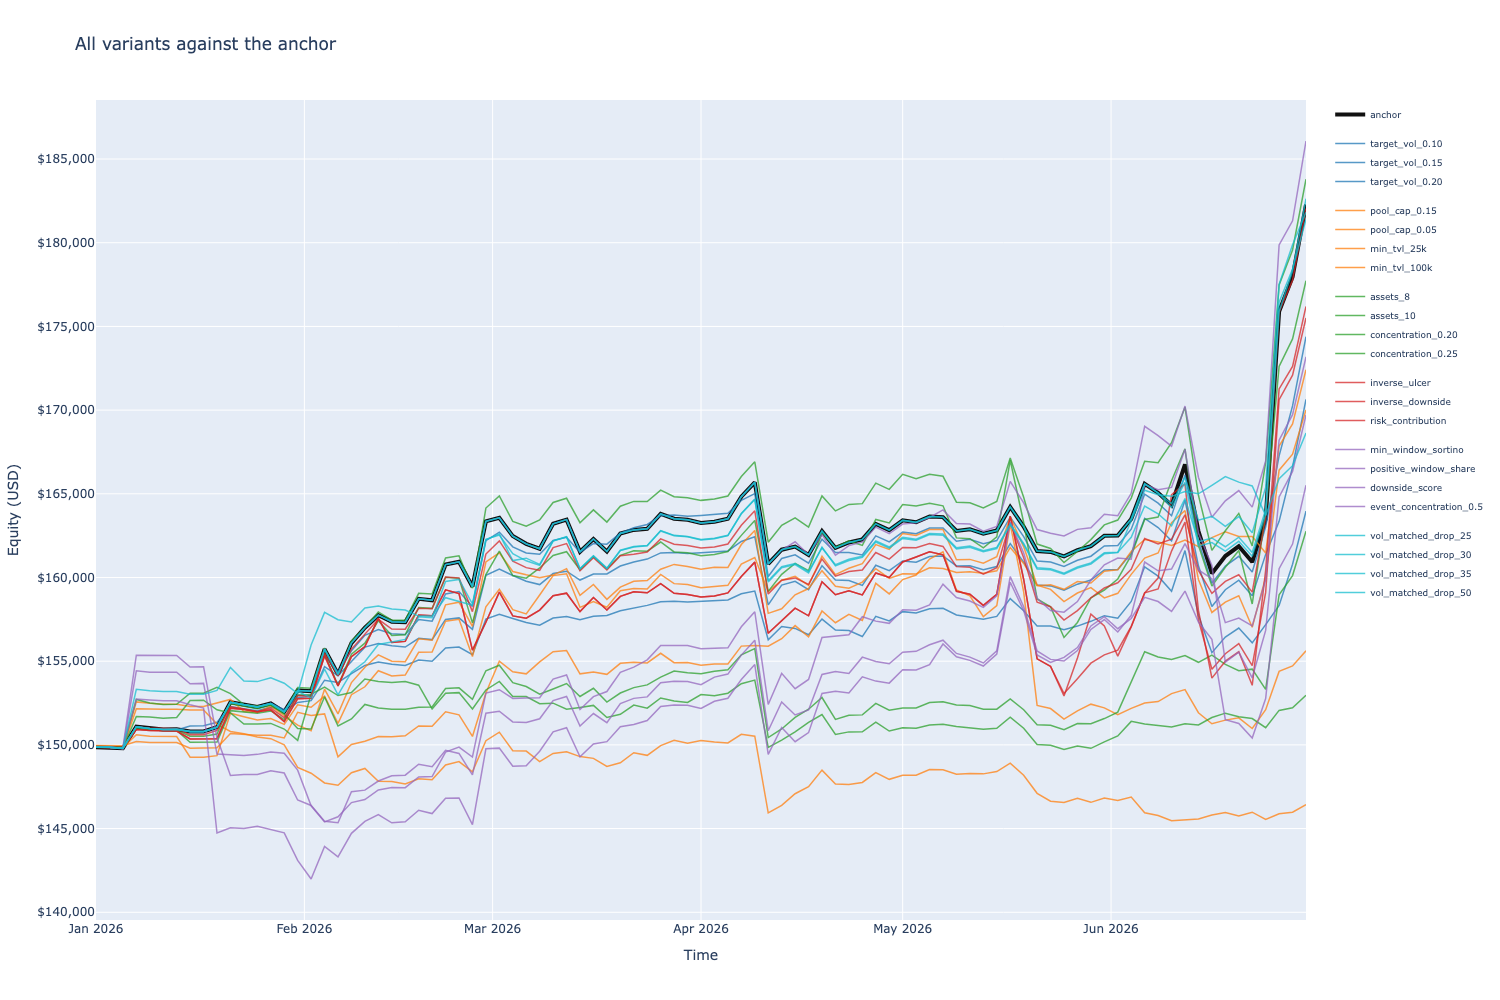

In [12]:
import plotly.graph_objects as go

FAMILY_COLOURS = {
    "anchor": "#111111",
    "NB04 vol target": "#1f77b4",
    "NB05 capacity": "#ff7f0e",
    "NB06 breadth/conc": "#2ca02c",
    "NB07 sizing": "#d62728",
    "NB09 selection": "#9467bd",
    "NB09 vol-matched": "#17becf",
}

def equity_figure(labels, title):
    fig = go.Figure()
    for label in labels:
        curve = equity_by_label[label]
        is_anchor = label == "anchor"
        fig.add_trace(go.Scatter(
            x=curve.index, y=curve.to_numpy(), name=label, mode="lines",
            line=dict(
                color=FAMILY_COLOURS.get(family_by_label[label], "#888888"),
                width=4 if is_anchor else 1.5,
                dash=None if is_anchor else "solid",
            ),
            opacity=1.0 if is_anchor else 0.75,
            legendgroup=family_by_label[label],
            hovertemplate="%{fullData.name}<br>%{x|%Y-%m-%d}<br>$%{y:,.0f}<extra></extra>",
        ))
    fig.update_layout(title=title, hovermode="x unified", legend=dict(font=dict(size=9)))
    fig.update_yaxes(title="Equity (USD)", tickformat="$,.0f")
    fig.update_xaxes(title="Time")
    return fig


equity_figure(list(equity_by_label), "All variants against the anchor").show()


## One family at a time

The combined chart is crowded by design - the point of it is the spread. These separate the
families so each can be read against the anchor on its own.


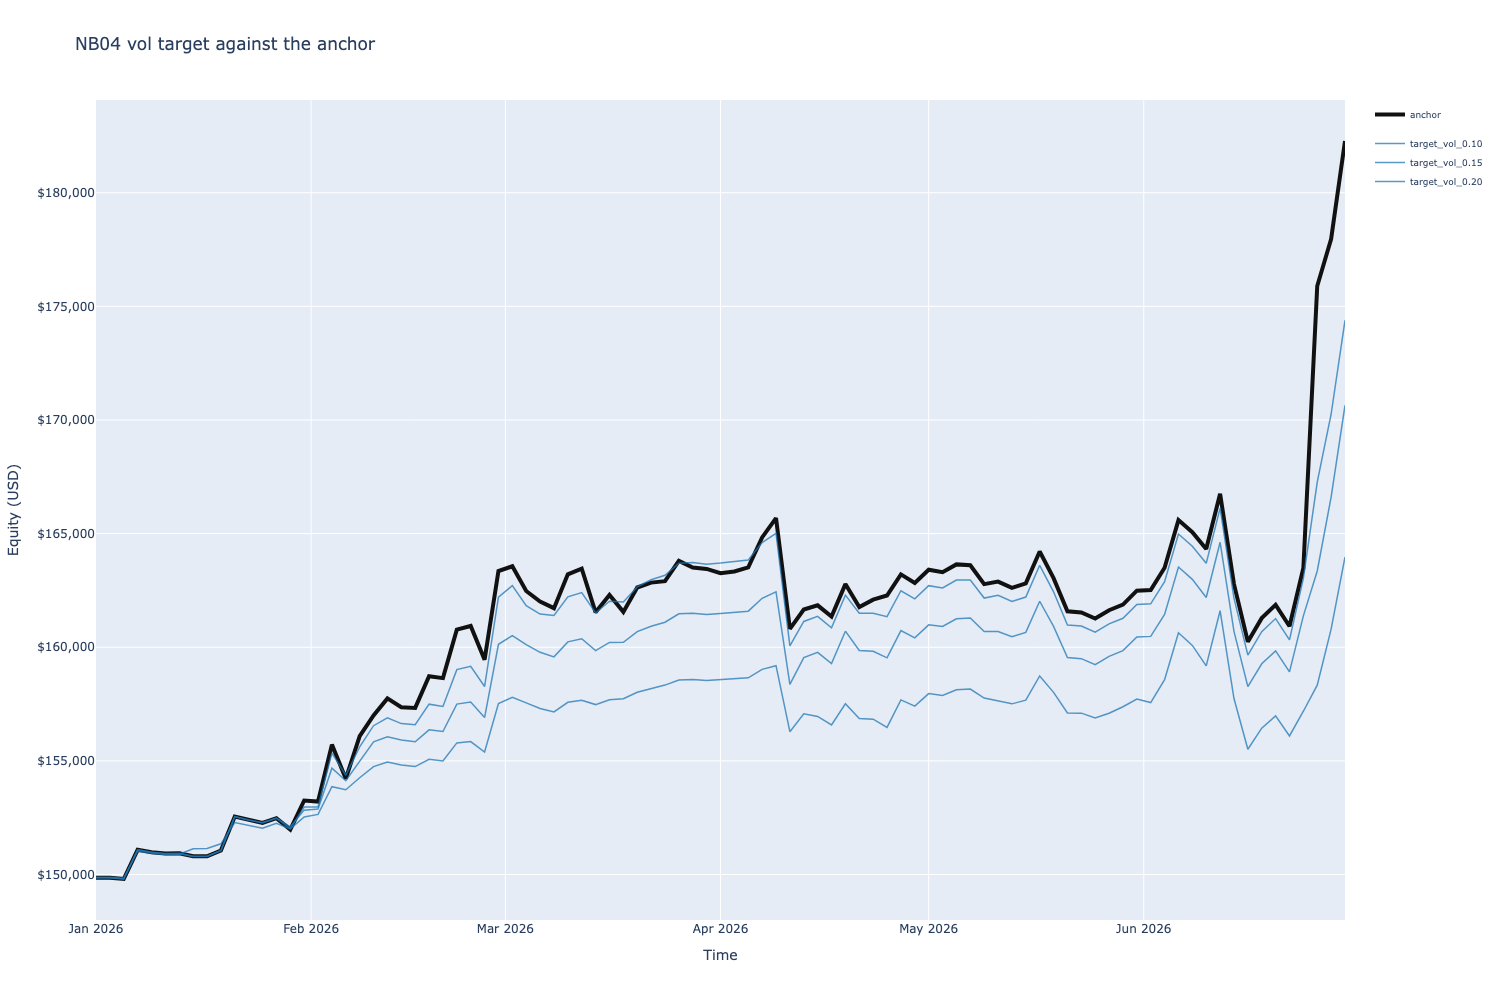

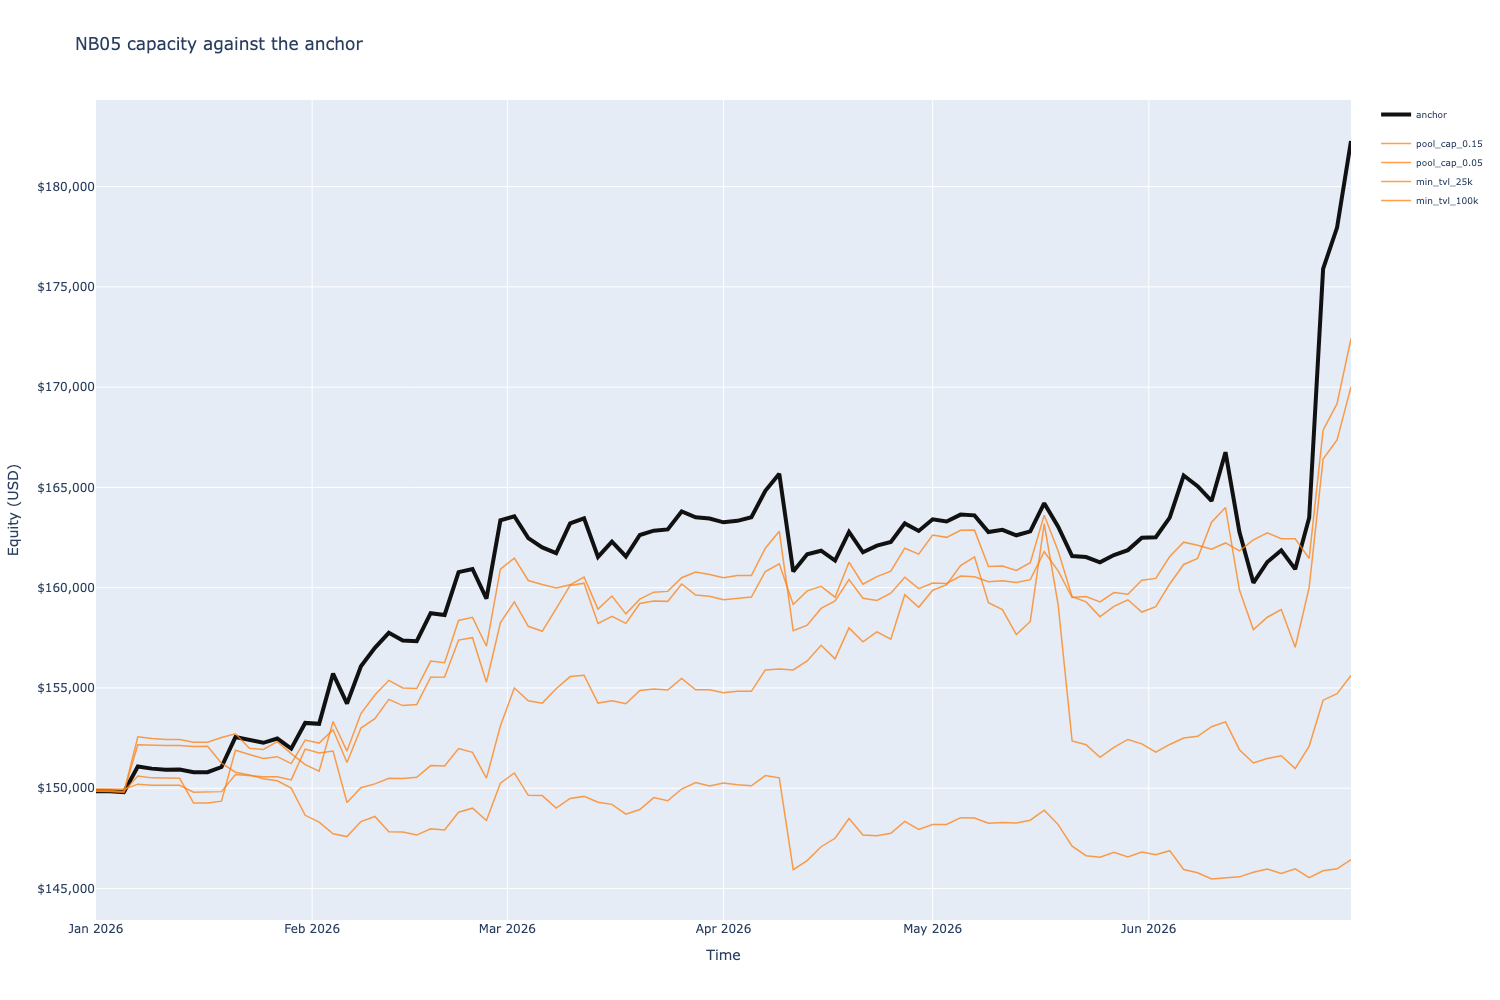

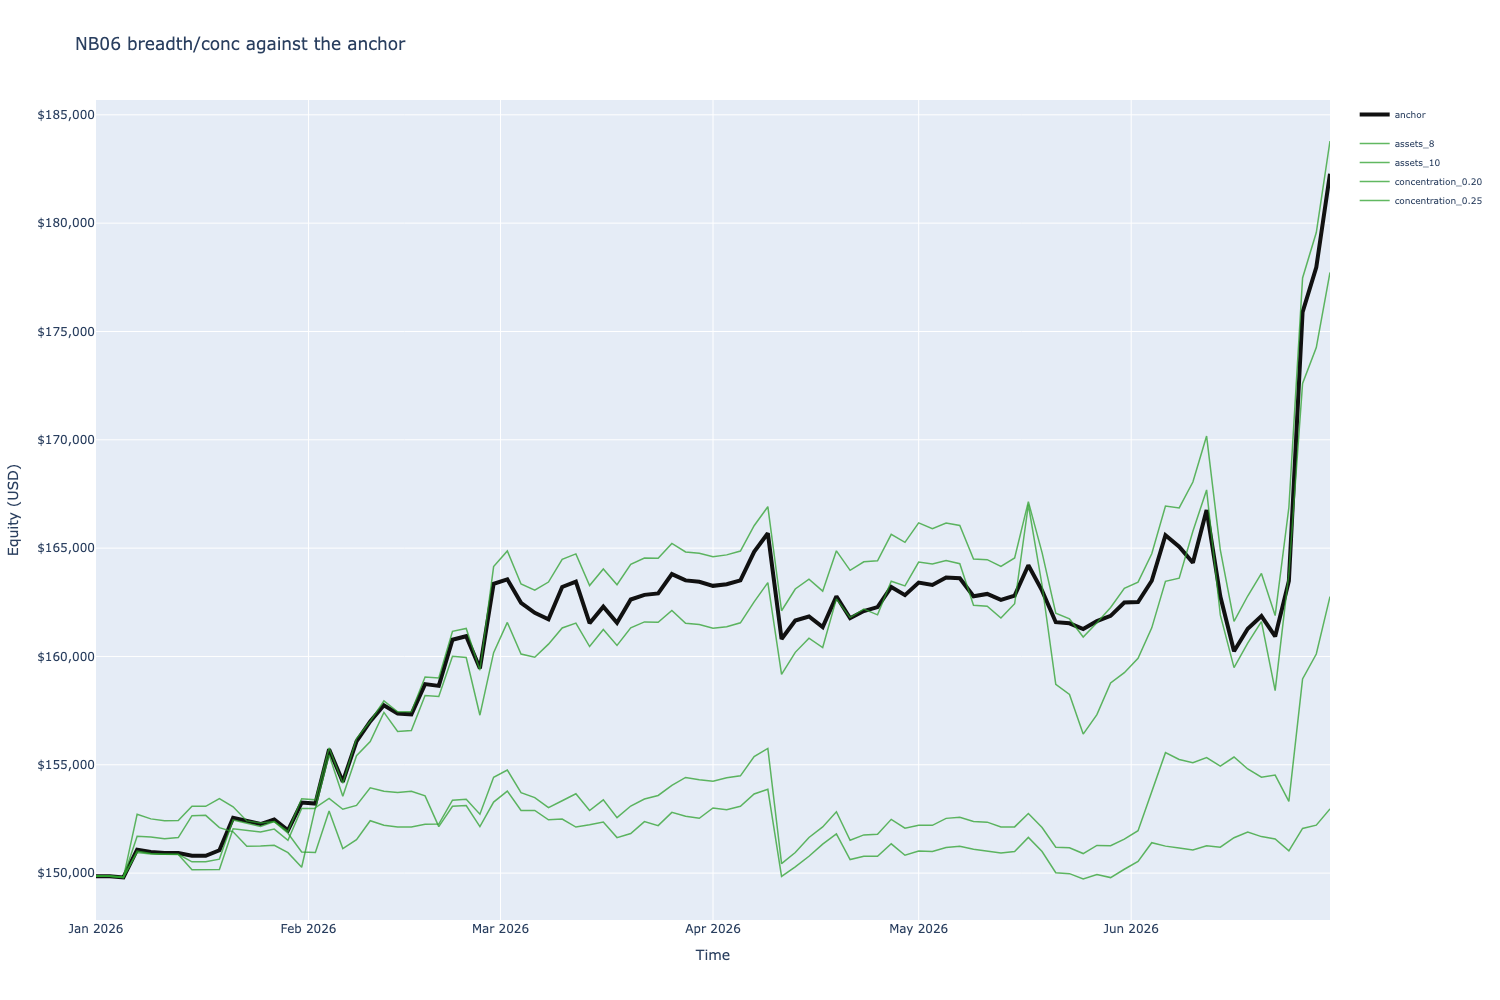

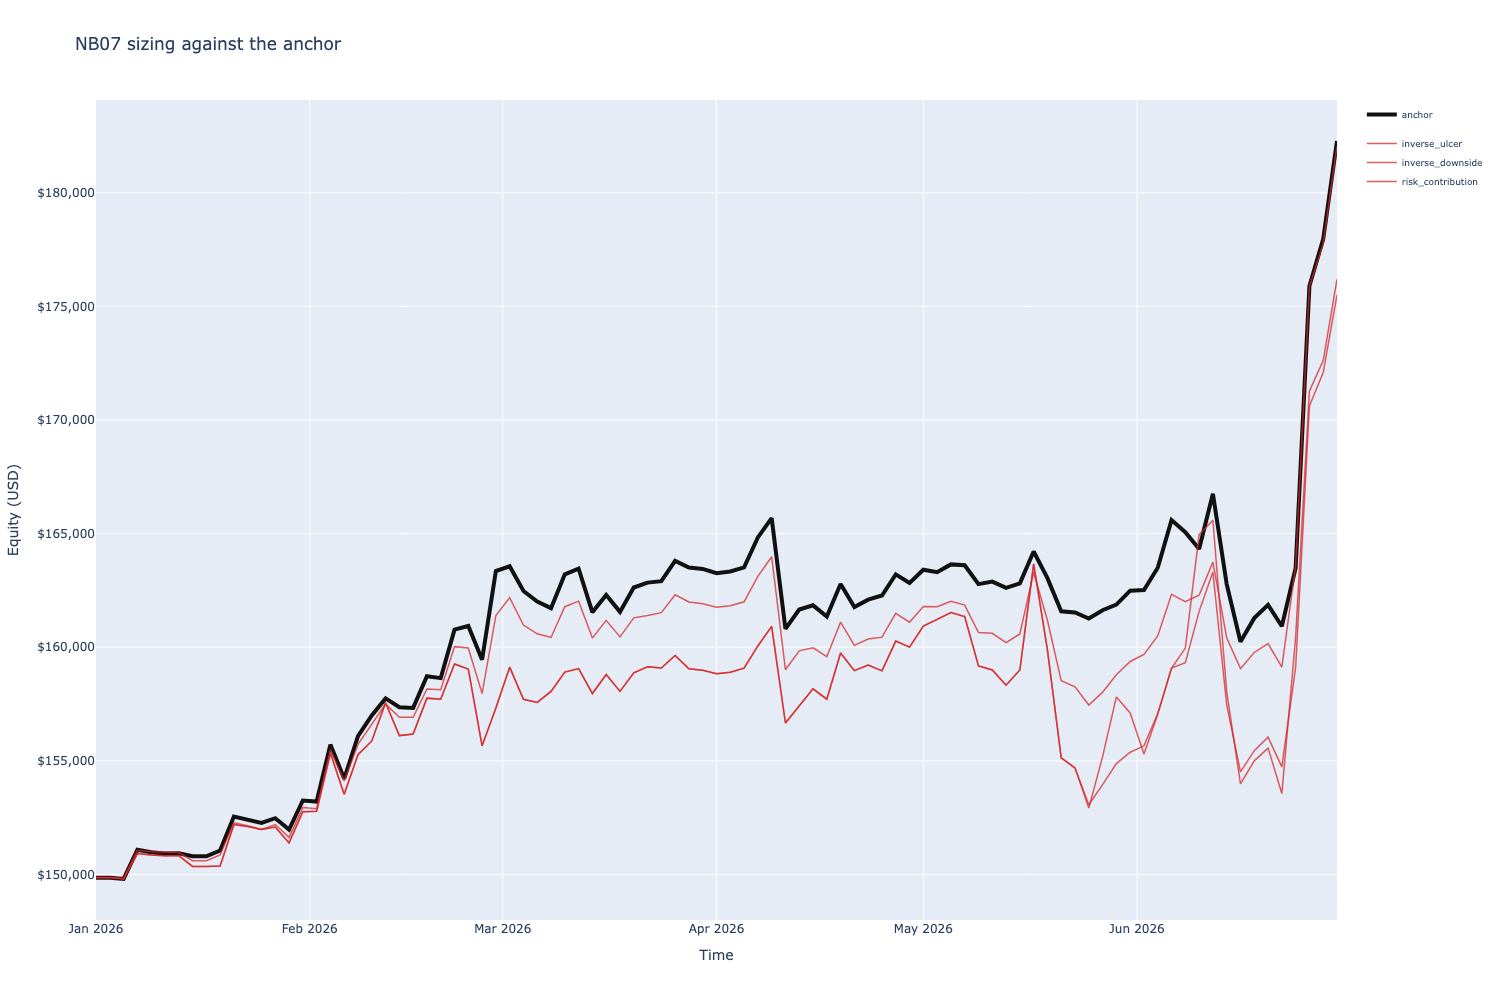

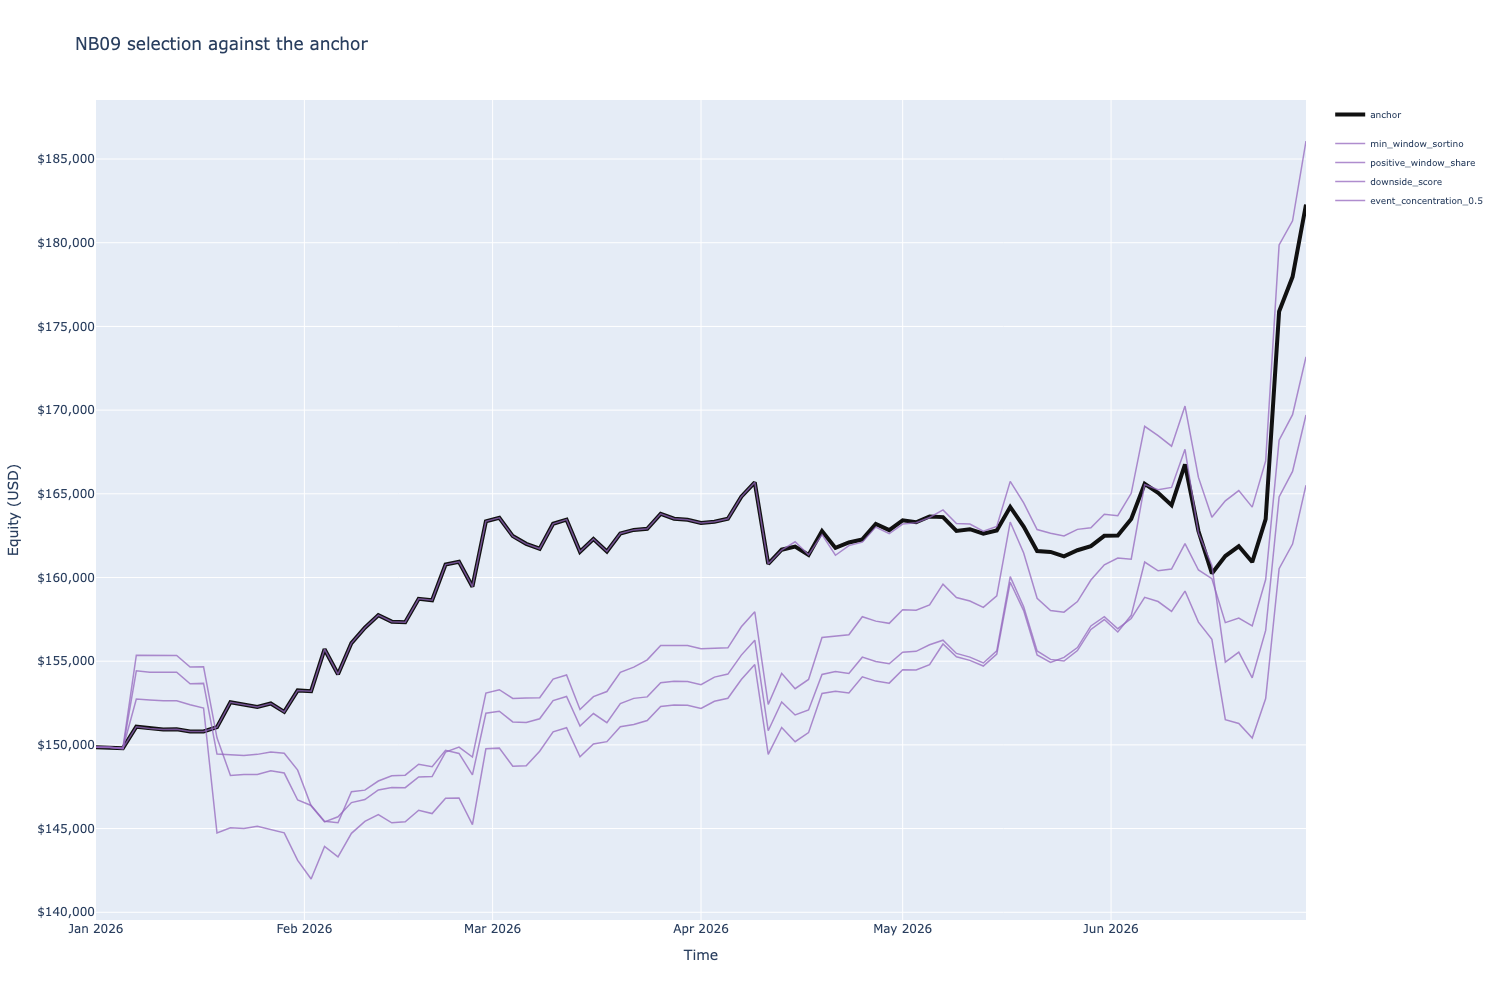

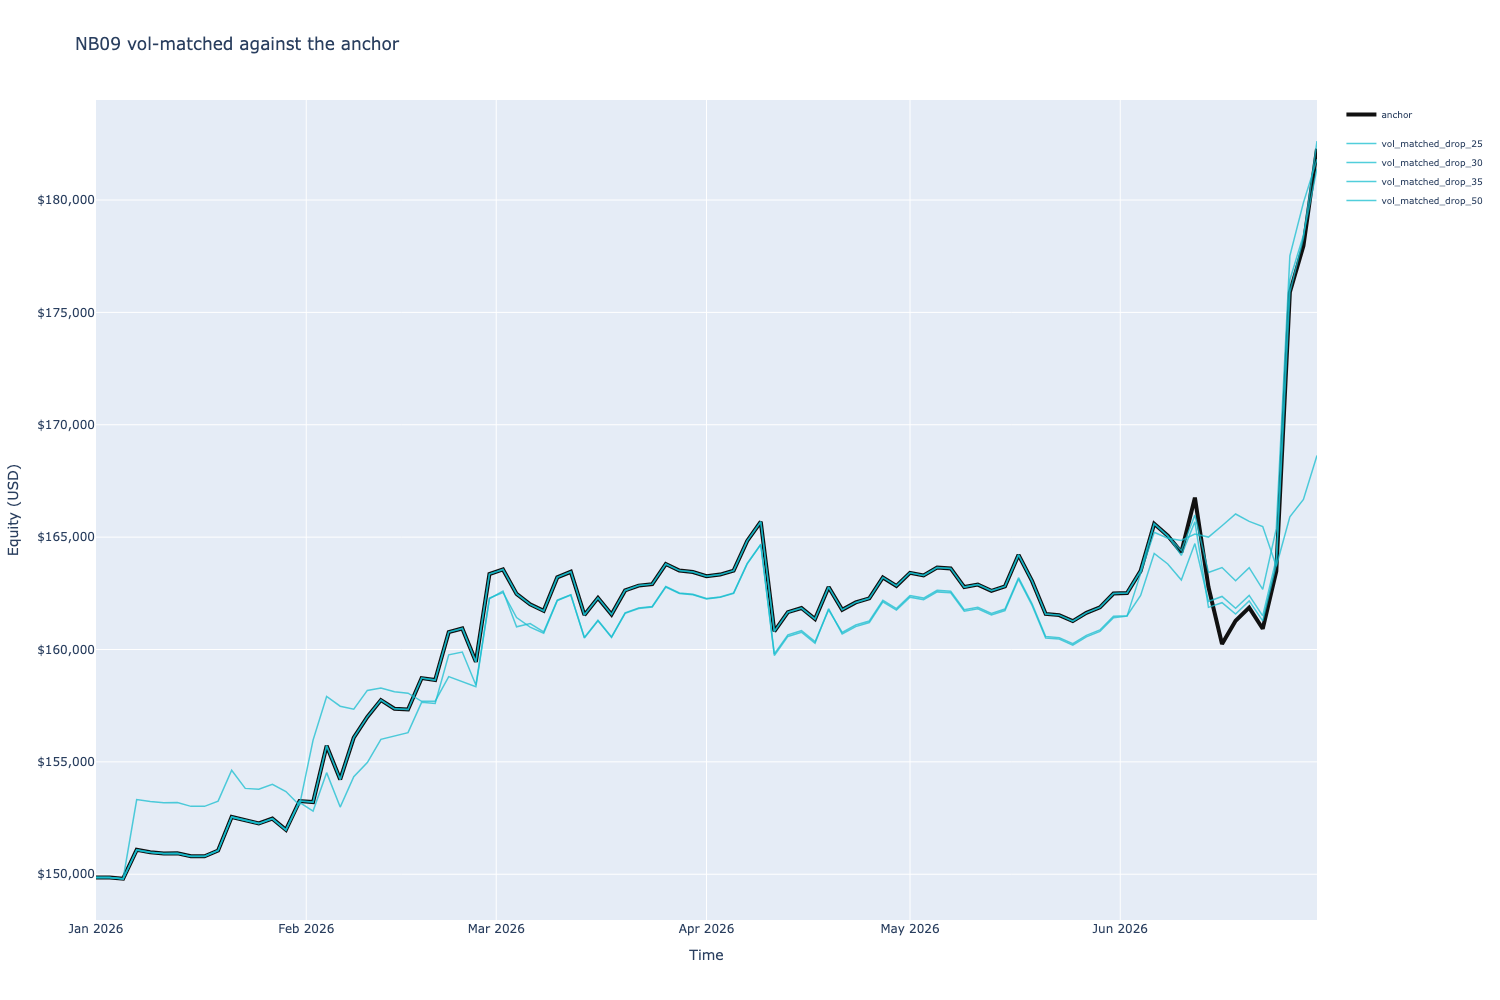

In [13]:
for family in ["NB04 vol target", "NB05 capacity", "NB06 breadth/conc",
               "NB07 sizing", "NB09 selection", "NB09 vol-matched"]:
    labels = ["anchor"] + [l for l, f in family_by_label.items() if f == family]
    equity_figure(labels, f"{family} against the anchor").show()


# Underwater curves

Drawdown from each run's own running peak. This is the shape the track was trying to improve, and
the ulcer index in the table above is the root-mean-square of these depths.


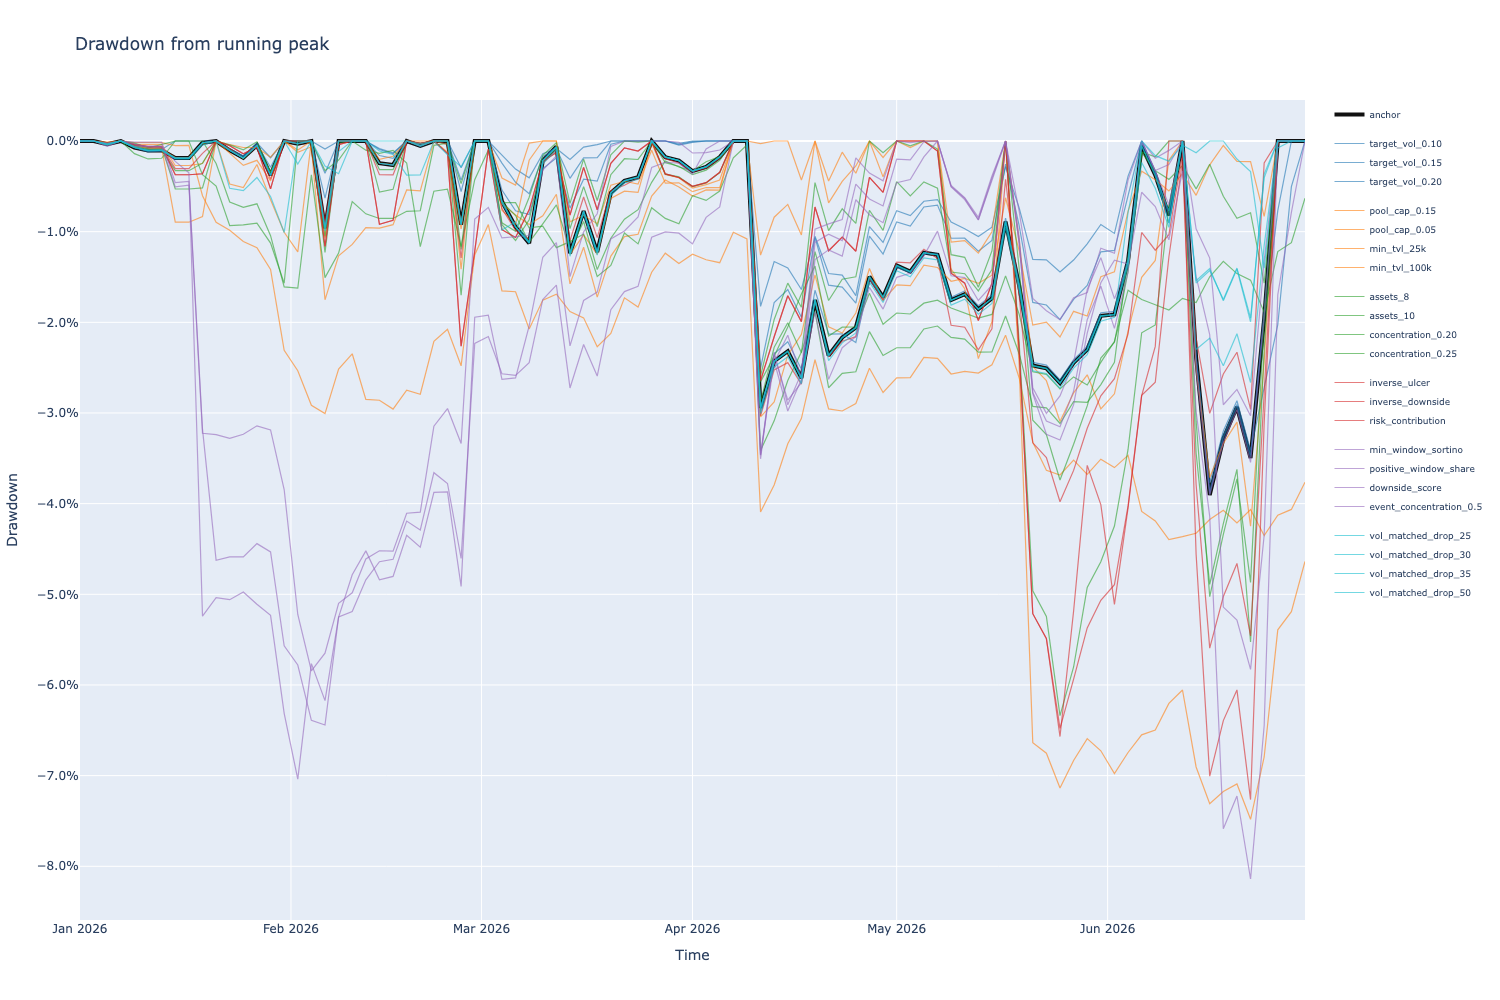

In [14]:
fig = go.Figure()
for label, curve in equity_by_label.items():
    drawdown = curve / curve.cummax() - 1.0
    is_anchor = label == "anchor"
    fig.add_trace(go.Scatter(
        x=drawdown.index, y=drawdown.to_numpy(), name=label, mode="lines",
        line=dict(color=FAMILY_COLOURS.get(family_by_label[label], "#888888"),
                  width=4 if is_anchor else 1.2),
        opacity=1.0 if is_anchor else 0.6,
        legendgroup=family_by_label[label],
        hovertemplate="%{fullData.name}<br>%{x|%Y-%m-%d}<br>%{y:.2%}<extra></extra>",
    ))
fig.update_layout(title="Drawdown from running peak", hovermode="x unified", legend=dict(font=dict(size=9)))
fig.update_yaxes(title="Drawdown", tickformat=".1%")
fig.update_xaxes(title="Time")
fig.show()


# The trade-off the track is actually about

Return against smoothness. Up and to the left is better: higher CAGR, lower ulcer index. The dashed
lines are the anchor's position, so the top-left quadrant is the region that beats it on both axes
at once. Marker size is invested-basket BTC beta - the second goal - so a small marker in the
top-left quadrant is what the track was looking for.


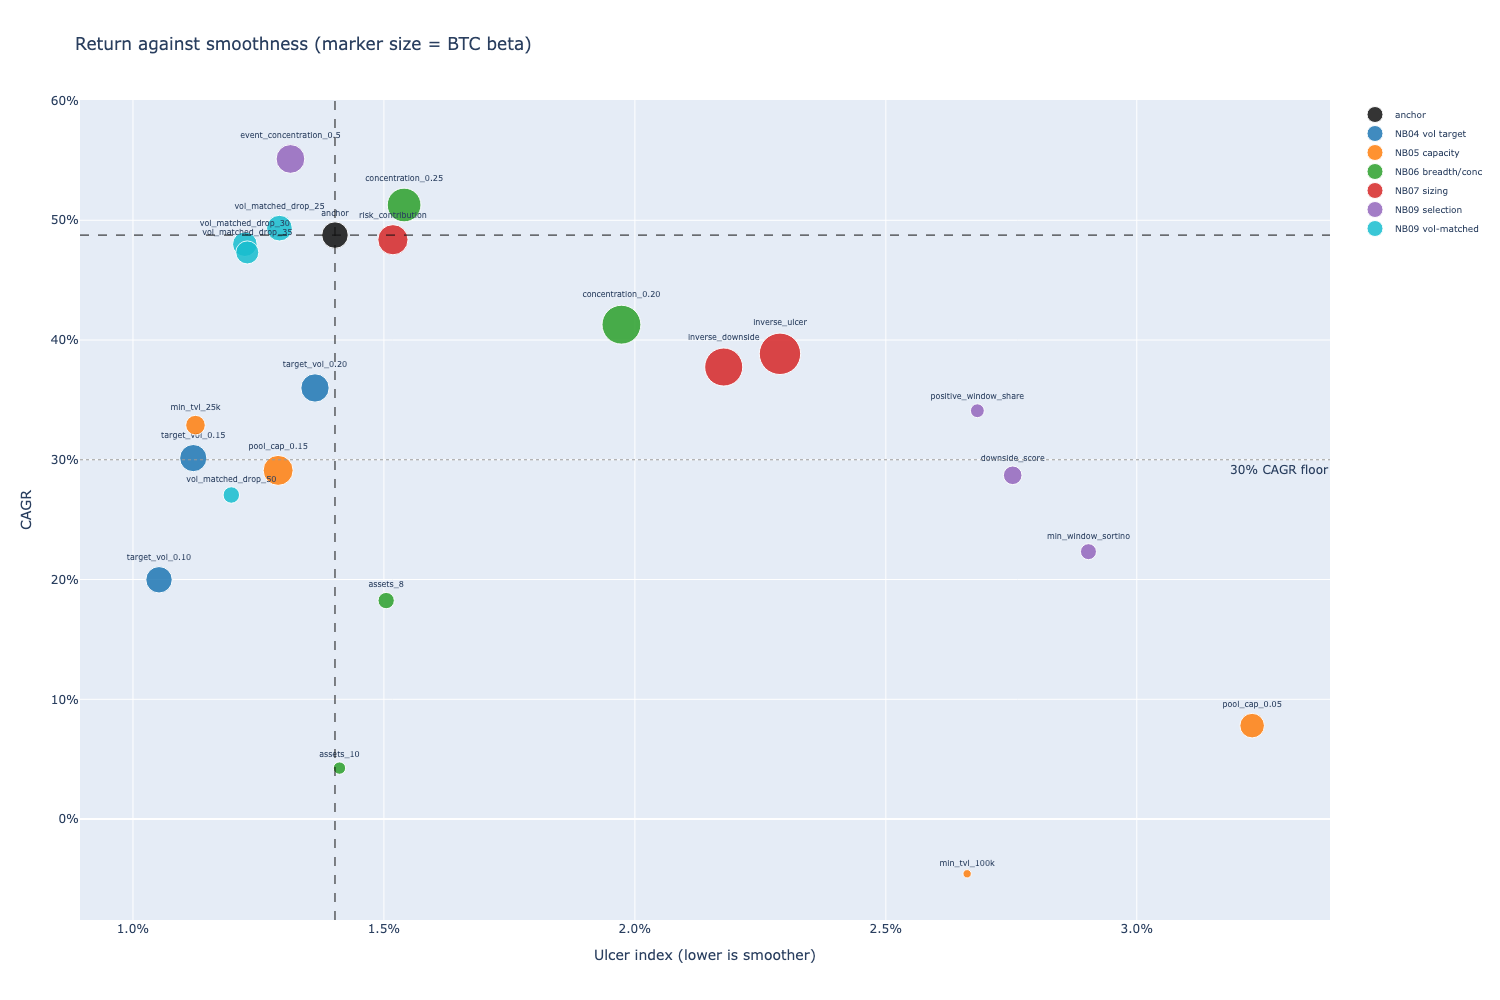

Variants beating the anchor on BOTH return and smoothness:
                             cagr     ulcer     martin  abs_invested_beta  passes
label                                                                            
event_concentration_0.5  0.551195  0.013138  41.955651           0.079738   False
vol_matched_drop_25      0.493415  0.012918  38.196720           0.068055    True


In [15]:
plot_df = comparison.reset_index()

fig = go.Figure()
for family in plot_df["family"].unique():
    subset = plot_df[plot_df["family"] == family]
    fig.add_trace(go.Scatter(
        x=subset["ulcer"], y=subset["cagr"], mode="markers+text",
        name=family, text=subset["label"], textposition="top center",
        textfont=dict(size=8),
        marker=dict(
            size=8 + 260 * subset["abs_invested_beta"],
            color=FAMILY_COLOURS.get(family, "#888888"),
            line=dict(width=1, color="white"),
            opacity=0.85,
        ),
        hovertemplate=("%{text}<br>CAGR %{y:.2%}<br>Ulcer %{x:.2%}"
                       "<br>Beta %{customdata:.4f}<extra></extra>"),
        customdata=subset["abs_invested_beta"],
    ))

fig.add_hline(y=float(anchor_panel["cagr"]), line=dict(dash="dash", color="#111111", width=1))
fig.add_vline(x=float(anchor_panel["ulcer"]), line=dict(dash="dash", color="#111111", width=1))
fig.add_hline(y=0.30, line=dict(dash="dot", color="#999999", width=1),
              annotation_text="30% CAGR floor", annotation_position="bottom right")
fig.update_layout(title="Return against smoothness (marker size = BTC beta)",
                  legend=dict(font=dict(size=9)))
fig.update_yaxes(title="CAGR", tickformat=".0%")
fig.update_xaxes(title="Ulcer index (lower is smoother)", tickformat=".1%")
fig.show()

better_both = comparison[
    (comparison["cagr"] > anchor_panel["cagr"]) & (comparison["ulcer"] < anchor_panel["ulcer"])
]
print("Variants beating the anchor on BOTH return and smoothness:")
print(better_both[["cagr", "ulcer", "martin", "abs_invested_beta", "passes"]].to_string()
      if len(better_both) else "  none")


# How each family fails

The adoption rule has five constraints and a variant needs all of them. This counts which
constraint each variant misses, so the families can be compared by failure mode rather than by
degree.


In [16]:
def failed_constraints(row):
    if row.name == "anchor":
        return []
    failures = []
    if not row["cagr"] >= 0.30:
        failures.append("CAGR < 30%")
    if not row["cycle_vol"] <= anchor_panel["cycle_vol"]:
        failures.append("volatility")
    if not row["ulcer"] < anchor_panel["ulcer"]:
        failures.append("ulcer")
    if not row["abs_invested_beta"] < anchor_panel["abs_invested_beta"]:
        failures.append("beta")
    if not row["mean_invested"] >= 0.45:
        failures.append("deployment")
    return failures

failure_rows = []
for label, row in comparison.iterrows():
    failures = failed_constraints(row)
    failure_rows.append({
        "label": label,
        "family": row["family"],
        "n_failed": len(failures),
        "failed": ", ".join(failures) if failures else "-- passes all --",
    })
failure_df = pd.DataFrame(failure_rows).set_index("label").sort_values(["n_failed", "family"])
display(failure_df)

print()
print("Constraint failure counts across all variants:")
counts = {}
for row in failure_rows:
    for f in row["failed"].split(", "):
        if f.startswith("--"):
            continue
        counts[f] = counts.get(f, 0) + 1
for constraint, n in sorted(counts.items(), key=lambda kv: -kv[1]):
    print(f"  {constraint:<12} {n} of {len(VARIANTS)} variants")


,family,n_failed,failed
label,,,
min_tvl_25k,NB05 capacity,0,-- passes all --
vol_matched_drop_25,NB09 vol-matched,0,-- passes all --
vol_matched_drop_30,NB09 vol-matched,0,-- passes all --
vol_matched_drop_35,NB09 vol-matched,0,-- passes all --
anchor,anchor,0,-- passes all --
target_vol_0.10,NB04 vol target,1,CAGR < 30%
target_vol_0.15,NB04 vol target,1,beta
target_vol_0.20,NB04 vol target,1,beta
positive_window_share,NB09 selection,1,ulcer



Constraint failure counts across all variants:
  ulcer        12 of 22 variants
  CAGR < 30%   9 of 22 variants
  beta         9 of 22 variants
  volatility   8 of 22 variants
